In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preparations and data loading

In [2]:
from pathlib import Path

DRIVE_ROOT = Path("/content/drive/MyDrive/Kernel_GLM_pseudo_labeling")
WORK_ROOT = Path("/content/Kernel_GLM_pseudo_labeling")
WORK_ROOT.mkdir(parents=True, exist_ok=True)

FEATURES_OUT = DRIVE_ROOT / "features_dinov2_camelyon17.npz"

print(FEATURES_OUT.exists(), FEATURES_OUT)

True /content/drive/MyDrive/Kernel_GLM_pseudo_labeling/features_dinov2_camelyon17.npz


In [3]:
import os
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt

In [4]:
def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)

set_seed(0)

In [7]:
data = np.load(FEATURES_OUT, allow_pickle=True)

X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

pca = PCA(n_components=256, whiten=True)
X_train_p = pca.fit_transform(X_train_s)
X_val_p   = pca.transform(X_val_s)
X_test_p  = pca.transform(X_test_s)

In [12]:
from sklearn.utils import resample

def subsample_per_class(X, y, n_per_class, random_state=42):
    classes = np.unique(y)
    X_sub, y_sub = [], []
    for c in classes:
        idx = np.where(y == c)[0]
        if len(idx) >= n_per_class:
            idx_sub = resample(idx, n_samples=n_per_class,
                             replace=False, random_state=random_state)
        else:
            idx_sub = idx  # keep all if class has fewer samples
        X_sub.append(X[idx_sub])
        y_sub.append(y[idx_sub])
    return np.concatenate(X_sub), np.concatenate(y_sub)

n_per_class=10, total=20


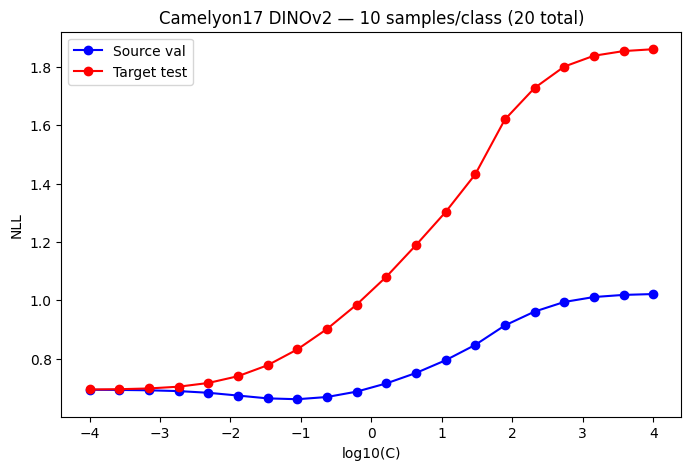

Source optimal C: 0.0886
Target optimal C: 0.0001
n_per_class=20, total=40


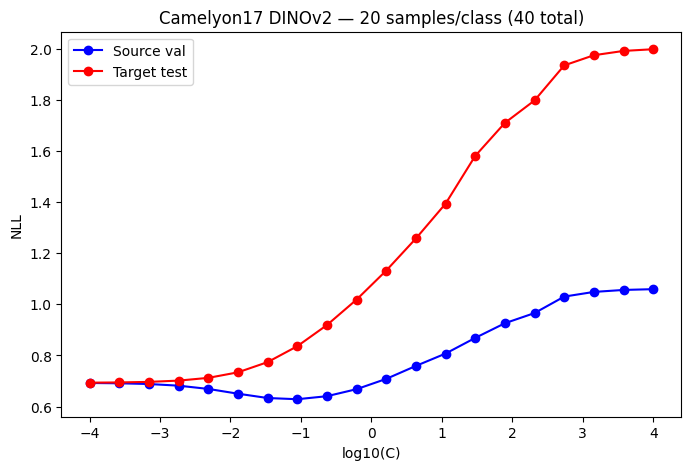

Source optimal C: 0.0886
Target optimal C: 0.0001
n_per_class=50, total=100


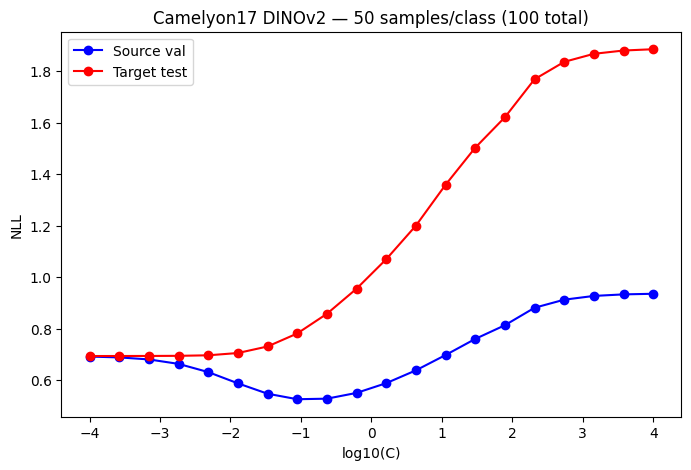

Source optimal C: 0.0886
Target optimal C: 0.0001
n_per_class=100, total=200


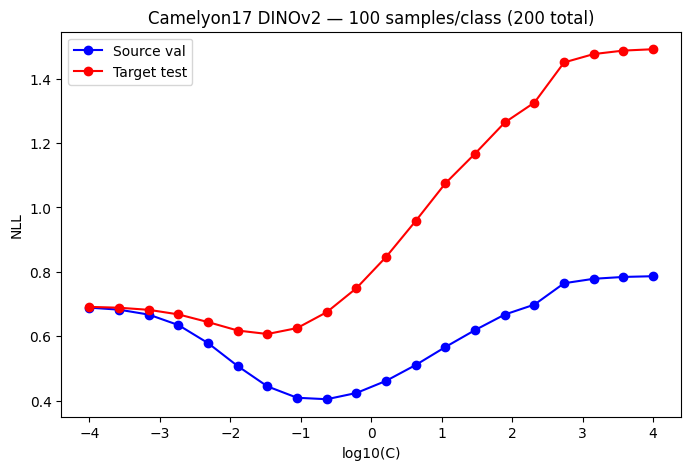

Source optimal C: 0.2336
Target optimal C: 0.0336


In [14]:
for n_per_class in [10, 20, 50, 100]:
    X_sub, y_sub = subsample_per_class(X_train_p, y_train, n_per_class)
    print(f"n_per_class={n_per_class}, total={len(X_sub)}")

    source_nlls, target_nlls = [], []
    for C in C_grid:
        clf = LogisticRegression(C=C, penalty="l2", solver="lbfgs",
                                 max_iter=1000)
        clf.fit(X_sub, y_sub)
        source_nlls.append(log_loss(y_val,  clf.predict_proba(X_val_p)))
        target_nlls.append(log_loss(y_test, clf.predict_proba(X_test_p)))

    plt.figure(figsize=(8, 5))
    plt.plot(np.log10(C_grid), source_nlls, "b-o", label="Source val")
    plt.plot(np.log10(C_grid), target_nlls, "r-o", label="Target test")
    plt.xlabel("log10(C)")
    plt.ylabel("NLL")
    plt.title(f"Camelyon17 DINOv2 — {n_per_class} samples/class ({len(X_sub)} total)")
    plt.legend()
    plt.show()

    print(f"Source optimal C: {C_grid[np.argmin(source_nlls)]:.4f}")
    print(f"Target optimal C: {C_grid[np.argmin(target_nlls)]:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' w

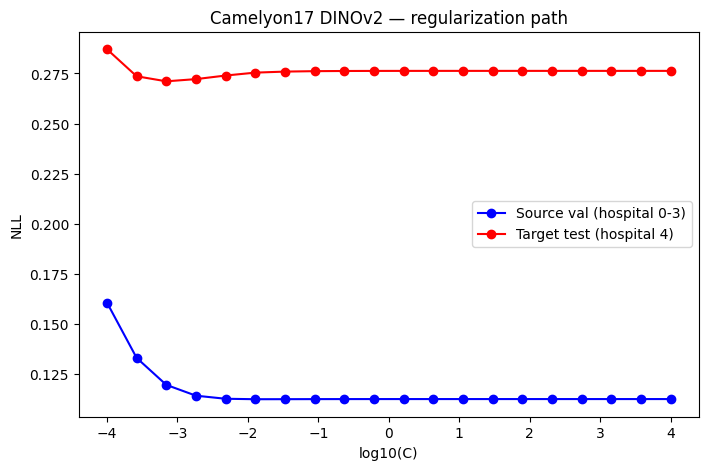

Source optimal C: 0.0127
Target optimal C: 0.0007
Gap: 3 grid steps


In [11]:
C_grid = np.logspace(-4, 4, 20)
source_nlls = []
target_nlls = []

for C in C_grid:
    clf = LogisticRegression(C=C, penalty="l2", solver="lbfgs",
                             max_iter=1000, multi_class="multinomial")
    clf.fit(X_train_p, y_train)

    source_nlls.append(log_loss(y_val,   clf.predict_proba(X_val_p)))
    target_nlls.append(log_loss(y_test,  clf.predict_proba(X_test_p)))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(np.log10(C_grid), source_nlls, "b-o", label="Source val (hospital 0-3)")
plt.plot(np.log10(C_grid), target_nlls, "r-o", label="Target test (hospital 4)")
plt.xlabel("log10(C)")
plt.ylabel("NLL")
plt.title("Camelyon17 DINOv2 — regularization path")
plt.legend()
plt.show()

print(f"Source optimal C: {C_grid[np.argmin(source_nlls)]:.4f}")
print(f"Target optimal C: {C_grid[np.argmin(target_nlls)]:.4f}")
print(f"Gap: {abs(np.argmin(source_nlls) - np.argmin(target_nlls))} grid steps")

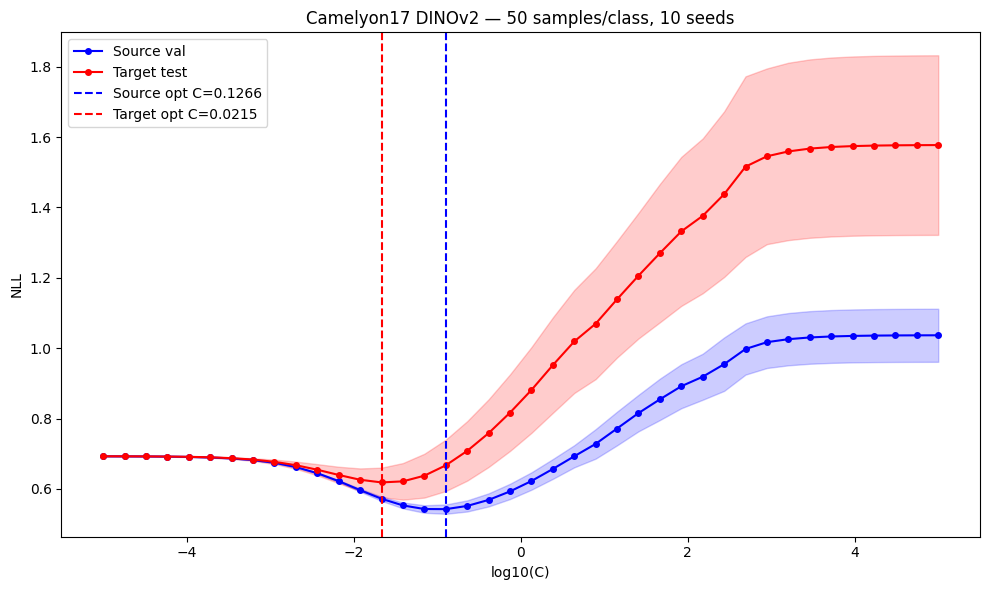

Source optimal C: 0.1266 (log10=-0.90)
Target optimal C: 0.0215 (log10=-1.67)
Gap in grid steps: 3
Source NLL at source opt: 0.5427
Target NLL at source opt: 0.6671
Target NLL at target opt: 0.6186
Suboptimality of naive: 0.0485


In [15]:
# Finer C grid
C_grid = np.logspace(-5, 5, 40)

# Multiple random seeds to check stability
n_seeds = 10
all_source_nlls = []
all_target_nlls = []

for seed in range(n_seeds):
    X_sub, y_sub = subsample_per_class(X_train_p, y_train,
                                        n_per_class=50, random_state=seed)
    source_nlls, target_nlls = [], []

    for C in C_grid:
        clf = LogisticRegression(C=C, penalty="l2", solver="lbfgs",
                                 max_iter=2000)
        clf.fit(X_sub, y_sub)
        source_nlls.append(log_loss(y_val,  clf.predict_proba(X_val_p)))
        target_nlls.append(log_loss(y_test, clf.predict_proba(X_test_p)))

    all_source_nlls.append(source_nlls)
    all_target_nlls.append(target_nlls)

all_source_nlls = np.array(all_source_nlls)
all_target_nlls = np.array(all_target_nlls)

# Compute stats
source_mean = all_source_nlls.mean(axis=0)
source_std  = all_source_nlls.std(axis=0)
target_mean = all_target_nlls.mean(axis=0)
target_std  = all_target_nlls.std(axis=0)

# Plot with confidence bands
log_C = np.log10(C_grid)
plt.figure(figsize=(10, 6))
plt.plot(log_C, source_mean, "b-o", label="Source val", markersize=4)
plt.fill_between(log_C, source_mean - source_std,
                         source_mean + source_std, alpha=0.2, color="b")
plt.plot(log_C, target_mean, "r-o", label="Target test", markersize=4)
plt.fill_between(log_C, target_mean - target_std,
                         target_mean + target_std, alpha=0.2, color="r")

# Mark optimal C for each
source_opt_idx = np.argmin(source_mean)
target_opt_idx = np.argmin(target_mean)
plt.axvline(log_C[source_opt_idx], color="b", linestyle="--",
            label=f"Source opt C={C_grid[source_opt_idx]:.4f}")
plt.axvline(log_C[target_opt_idx], color="r", linestyle="--",
            label=f"Target opt C={C_grid[target_opt_idx]:.4f}")

plt.xlabel("log10(C)")
plt.ylabel("NLL")
plt.title("Camelyon17 DINOv2 — 50 samples/class, 10 seeds")
plt.legend()
plt.tight_layout()
plt.show()

# Summary
print(f"Source optimal C: {C_grid[source_opt_idx]:.4f} "
      f"(log10={log_C[source_opt_idx]:.2f})")
print(f"Target optimal C: {C_grid[target_opt_idx]:.4f} "
      f"(log10={log_C[target_opt_idx]:.2f})")
print(f"Gap in grid steps: {abs(source_opt_idx - target_opt_idx)}")
print(f"Source NLL at source opt: {source_mean[source_opt_idx]:.4f}")
print(f"Target NLL at source opt: {target_mean[source_opt_idx]:.4f}")
print(f"Target NLL at target opt: {target_mean[target_opt_idx]:.4f}")
print(f"Suboptimality of naive: "
      f"{target_mean[source_opt_idx] - target_mean[target_opt_idx]:.4f}")

Seed 1/20... naive=0.7464  pseudo=0.6500  oracle=0.6500
Seed 2/20... naive=0.6940  pseudo=0.6594  oracle=0.6544
Seed 3/20... naive=0.8176  pseudo=0.6931  oracle=0.6913
Seed 4/20... naive=0.5892  pseudo=0.5932  oracle=0.5869
Seed 5/20... naive=0.5328  pseudo=0.5750  oracle=0.5328
Seed 6/20... naive=0.5650  pseudo=0.5733  oracle=0.5575
Seed 7/20... naive=0.6037  pseudo=0.6011  oracle=0.5985
Seed 8/20... naive=0.6112  pseudo=0.6209  oracle=0.6042
Seed 9/20... naive=0.8050  pseudo=0.6694  oracle=0.6667
Seed 10/20... naive=0.5438  pseudo=0.5565  oracle=0.5403
Seed 11/20... naive=0.7040  pseudo=0.6366  oracle=0.6302
Seed 12/20... naive=0.7410  pseudo=0.6686  oracle=0.6578
Seed 13/20... naive=0.5979  pseudo=0.6010  oracle=0.5897
Seed 14/20... naive=0.7000  pseudo=0.6587  oracle=0.6587
Seed 15/20... naive=0.7946  pseudo=0.6647  oracle=0.6647
Seed 16/20... naive=0.8541  pseudo=0.6924  oracle=0.6916
Seed 17/20... naive=0.5387  pseudo=0.5387  oracle=0.5387
Seed 18/20... naive=0.7444  pseudo=0.642

/tmp/ipykernel_13212/3068038316.py:120: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([all_results["naive"], all_results["pseudo"],
/tmp/ipykernel_13212/3068038316.py:127: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([np.log10(all_C["naive"]), np.log10(all_C["pseudo"]),


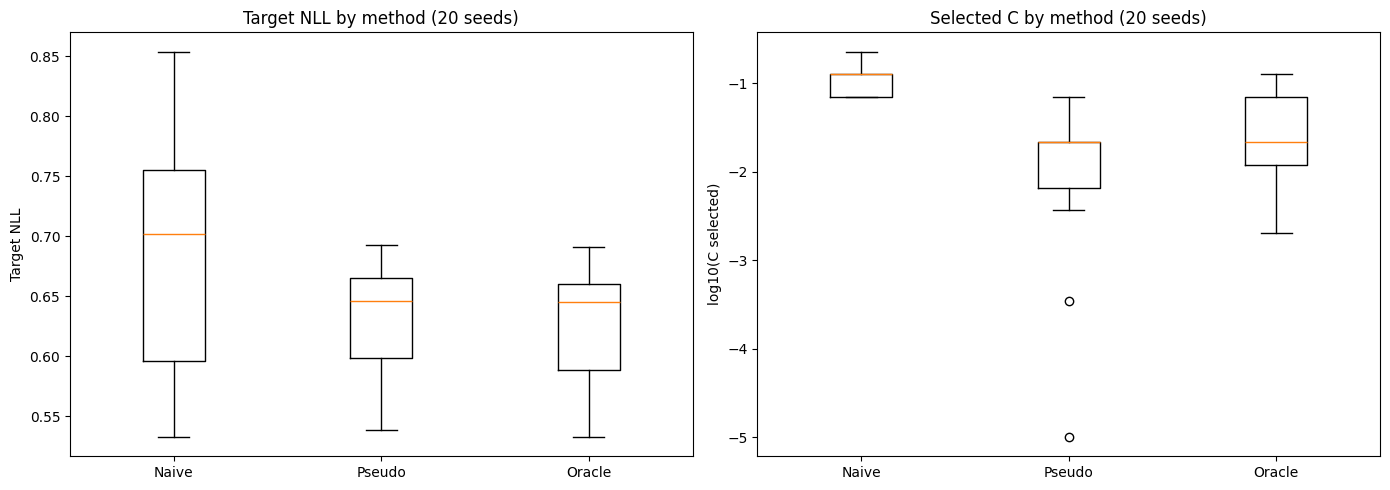

In [17]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.utils import resample
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
N_D1_PER_CLASS = 50
N_D2_PER_CLASS = 200
N_SEEDS        = 20
C_GRID         = np.logspace(-5, 5, 40)

# ── Load features ─────────────────────────────────────────────────────────────
data    = np.load(DRIVE_ROOT / "features_dinov2_camelyon17.npz")
X_train = data["X_train"];  y_train = data["y_train"]
X_val   = data["X_val"];    y_val   = data["y_val"]
X_test  = data["X_test"];   y_test  = data["y_test"]

# ── Preprocessing ─────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

pca = PCA(n_components=256, whiten=True)
X_train_p = pca.fit_transform(X_train_s)
X_val_p   = pca.transform(X_val_s)
X_test_p  = pca.transform(X_test_s)

# ── Core function ─────────────────────────────────────────────────────────────
def run_pseudo_labeling(X_train_p, y_train, X_test_p, y_test,
                         C_grid, seed=0):
    rng     = np.random.default_rng(seed)
    classes = np.unique(y_train)
    D1_idx, D2_idx = [], []

    for c in classes:
        idx_c = np.where(y_train == c)[0]
        idx_c = rng.permutation(idx_c)
        D1_idx.extend(idx_c[:N_D1_PER_CLASS])
        D2_idx.extend(idx_c[N_D1_PER_CLASS:N_D1_PER_CLASS + N_D2_PER_CLASS])

    D1_idx = np.array(D1_idx)
    D2_idx = np.array(D2_idx)
    X1, y1 = X_train_p[D1_idx], y_train[D1_idx]
    X2, y2 = X_train_p[D2_idx], y_train[D2_idx]

    # Imputer on D2 — largest C in grid
    imputer = LogisticRegression(C=C_grid.max(), penalty="l2",
                                  solver="lbfgs", max_iter=2000)
    imputer.fit(X2, y2)
    pseudo_labels = imputer.predict_proba(X_test_p)

    # Sweep candidates on D1
    pseudo_risks, naive_risks, oracle_risks = [], [], []

    for C in C_grid:
        clf = LogisticRegression(C=C, penalty="l2", solver="lbfgs",
                                  max_iter=2000)
        clf.fit(X1, y1)

        proba_target = clf.predict_proba(X_test_p)
        pseudo_risk  = -np.mean(np.sum(pseudo_labels *
                                np.log(proba_target + 1e-10), axis=1))
        pseudo_risks.append(pseudo_risk)
        naive_risks.append(log_loss(y2,    clf.predict_proba(X2)))
        oracle_risks.append(log_loss(y_test, clf.predict_proba(X_test_p)))

    C_pseudo = C_grid[np.argmin(pseudo_risks)]
    C_naive  = C_grid[np.argmin(naive_risks)]
    C_oracle = C_grid[np.argmin(oracle_risks)]

    results = {}
    for name, C_sel in [("pseudo", C_pseudo),
                         ("naive",  C_naive),
                         ("oracle", C_oracle)]:
        clf = LogisticRegression(C=C_sel, penalty="l2", solver="lbfgs",
                                  max_iter=2000)
        clf.fit(X1, y1)
        nll = log_loss(y_test, clf.predict_proba(X_test_p))
        results[name] = {"C_selected": C_sel, "nll": nll}

    return results

# ── Run over seeds ────────────────────────────────────────────────────────────
all_results = {"pseudo": [], "naive": [], "oracle": []}
all_C       = {"pseudo": [], "naive": [], "oracle": []}

for seed in range(N_SEEDS):
    print(f"Seed {seed+1}/{N_SEEDS}...", end=" ")
    res = run_pseudo_labeling(X_train_p, y_train, X_test_p, y_test,
                               C_grid=C_GRID, seed=seed)
    for method in all_results:
        all_results[method].append(res[method]["nll"])
        all_C[method].append(res[method]["C_selected"])
    print(f"naive={res['naive']['nll']:.4f}  "
          f"pseudo={res['pseudo']['nll']:.4f}  "
          f"oracle={res['oracle']['nll']:.4f}")

# ── Report ────────────────────────────────────────────────────────────────────
print(f"\n{'Method':<10} {'Mean NLL':>10} {'Std':>8} {'95% CI':>22} "
      f"{'Mean C':>10}")
print("-" * 65)
for method in ["naive", "pseudo", "oracle"]:
    nlls = np.array(all_results[method])
    Cs   = np.array(all_C[method])
    mean = nlls.mean()
    std  = nlls.std()
    ci   = 1.96 * std / np.sqrt(len(nlls))
    print(f"{method:<10} {mean:>10.4f} {std:>8.4f} "
          f"[{mean-ci:.4f}, {mean+ci:.4f}]  {Cs.mean():>10.4f}")

# ── Plot NLL distributions ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: NLL boxplot
axes[0].boxplot([all_results["naive"], all_results["pseudo"],
                  all_results["oracle"]],
                 labels=["Naive", "Pseudo", "Oracle"])
axes[0].set_ylabel("Target NLL")
axes[0].set_title("Target NLL by method (20 seeds)")

# Right: selected C distributions
axes[1].boxplot([np.log10(all_C["naive"]), np.log10(all_C["pseudo"]),
                  np.log10(all_C["oracle"])],
                 labels=["Naive", "Pseudo", "Oracle"])
axes[1].set_ylabel("log10(C selected)")
axes[1].set_title("Selected C by method (20 seeds)")

plt.tight_layout()
plt.show()


D2 size: 100 per class (200 total for binary)
  Seed 10/100 — naive=0.6486  pseudo=0.6359  oracle=0.6083
  Seed 20/100 — naive=0.6900  pseudo=0.6433  oracle=0.6246
  Seed 30/100 — naive=0.6826  pseudo=0.6435  oracle=0.6212
  Seed 40/100 — naive=0.6777  pseudo=0.6473  oracle=0.6164
  Seed 50/100 — naive=0.6789  pseudo=0.6464  oracle=0.6189
  Seed 60/100 — naive=0.6832  pseudo=0.6492  oracle=0.6194
  Seed 70/100 — naive=0.6873  pseudo=0.6483  oracle=0.6210
  Seed 80/100 — naive=0.6837  pseudo=0.6458  oracle=0.6205
  Seed 90/100 — naive=0.6818  pseudo=0.6443  oracle=0.6201
  Seed 100/100 — naive=0.6821  pseudo=0.6451  oracle=0.6211

D2 size: 200 per class (400 total for binary)
  Seed 10/100 — naive=0.6509  pseudo=0.6192  oracle=0.6083
  Seed 20/100 — naive=0.6853  pseudo=0.6323  oracle=0.6246
  Seed 30/100 — naive=0.6751  pseudo=0.6304  oracle=0.6212
  Seed 40/100 — naive=0.6696  pseudo=0.6329  oracle=0.6164
  Seed 50/100 — naive=0.6748  pseudo=0.6342  oracle=0.6189
  Seed 60/100 — naiv

/tmp/ipykernel_13212/3370859253.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([res["nll"]["naive"],
/tmp/ipykernel_13212/3370859253.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([res["nll"]["naive"],
/tmp/ipykernel_13212/3370859253.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([res["nll"]["naive"],


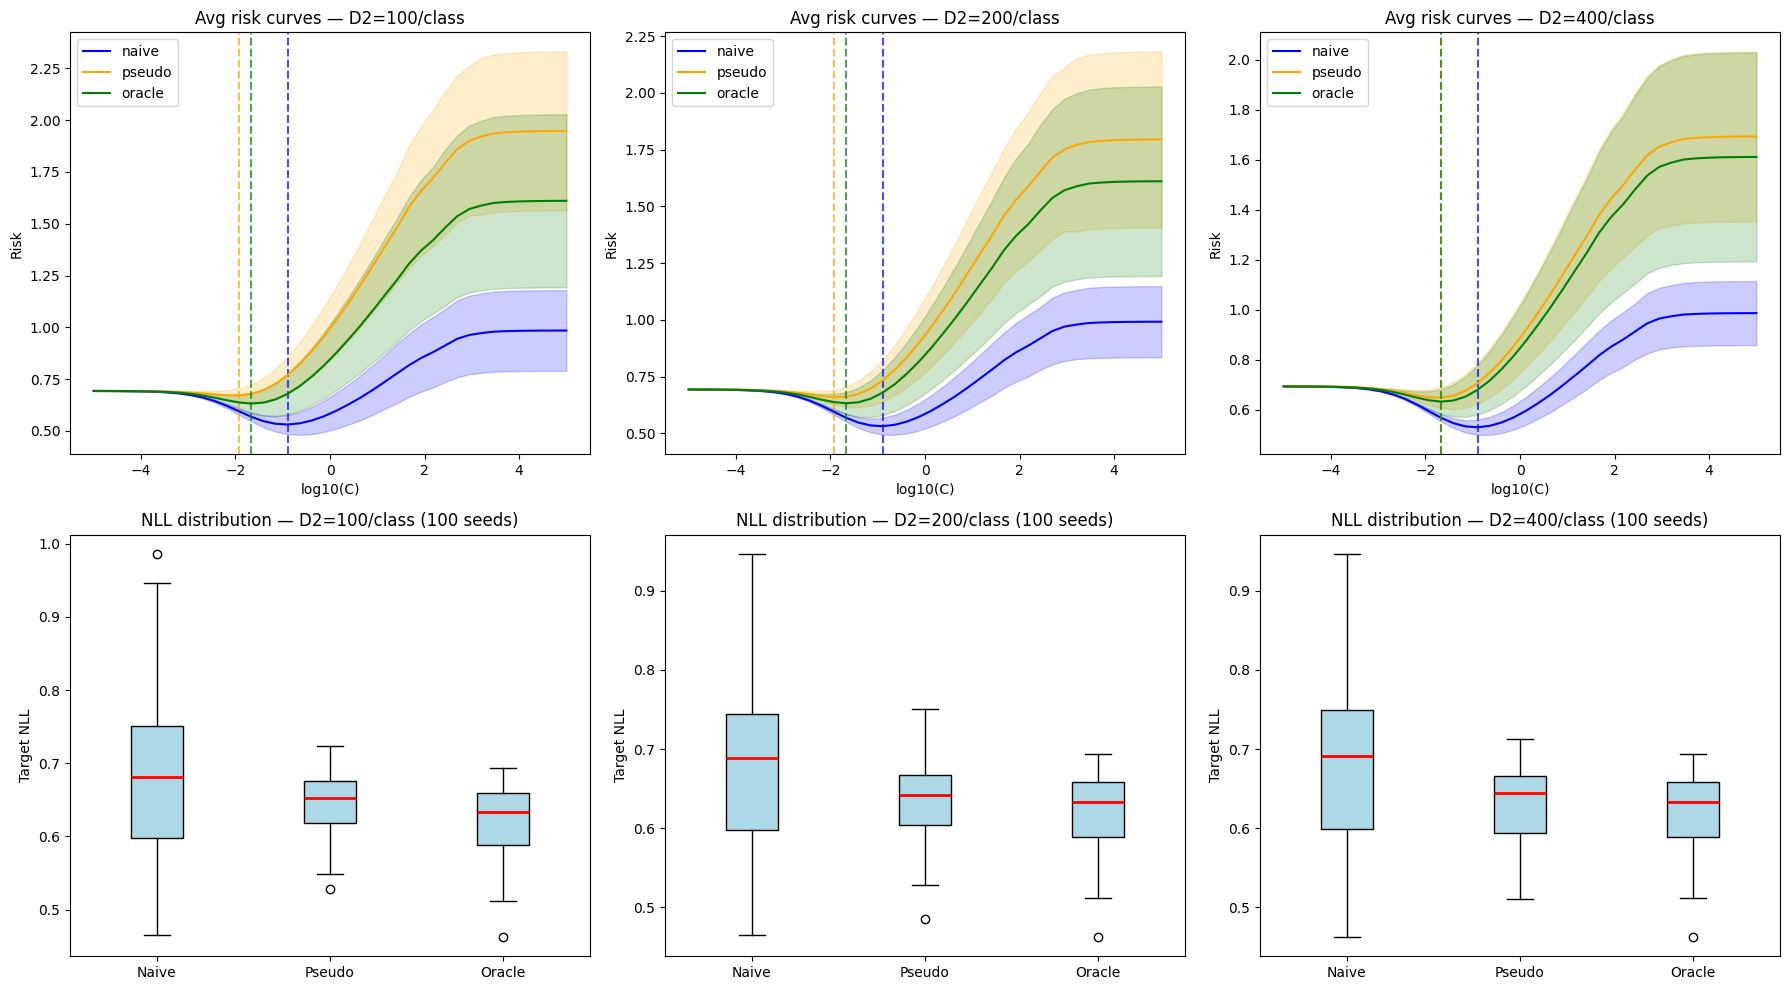

In [18]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
N_D1_PER_CLASS = 50
N_SEEDS        = 100
C_GRID         = np.logspace(-5, 5, 40)
D2_SIZES       = [100, 200, 400]   # sensitivity analysis on imputer size

# ── Load features ─────────────────────────────────────────────────────────────
data    = np.load(DRIVE_ROOT / "features_dinov2_camelyon17.npz")
X_train = data["X_train"];  y_train = data["y_train"]
X_test  = data["X_test"];   y_test  = data["y_test"]

# ── Preprocessing ─────────────────────────────────────────────────────────────
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

pca       = PCA(n_components=256, whiten=True)
X_train_p = pca.fit_transform(X_train_s)
X_test_p  = pca.transform(X_test_s)

# ── Core function ─────────────────────────────────────────────────────────────
def run_pseudo_labeling(X_train_p, y_train, X_test_p, y_test,
                         C_grid, n_d2_per_class, seed=0):
    rng     = np.random.default_rng(seed)
    classes = np.unique(y_train)
    D1_idx, D2_idx = [], []

    for c in classes:
        idx_c = np.where(y_train == c)[0]
        idx_c = rng.permutation(idx_c)
        D1_idx.extend(idx_c[:N_D1_PER_CLASS])
        D2_idx.extend(idx_c[N_D1_PER_CLASS:N_D1_PER_CLASS + n_d2_per_class])

    D1_idx = np.array(D1_idx)
    D2_idx = np.array(D2_idx)
    X1, y1 = X_train_p[D1_idx], y_train[D1_idx]
    X2, y2 = X_train_p[D2_idx], y_train[D2_idx]

    # Imputer on D2 — largest C in grid
    imputer = LogisticRegression(C=C_grid.max(), penalty="l2",
                                  solver="lbfgs", max_iter=2000)
    imputer.fit(X2, y2)
    pseudo_labels = imputer.predict_proba(X_test_p)

    # Sweep candidates on D1
    pseudo_risks, naive_risks, oracle_risks = [], [], []

    for C in C_grid:
        clf = LogisticRegression(C=C, penalty="l2", solver="lbfgs",
                                  max_iter=2000)
        clf.fit(X1, y1)

        proba_target = clf.predict_proba(X_test_p)
        pseudo_risk  = -np.mean(np.sum(pseudo_labels *
                                np.log(proba_target + 1e-10), axis=1))
        pseudo_risks.append(pseudo_risk)
        naive_risks.append(log_loss(y2,     clf.predict_proba(X2)))
        oracle_risks.append(log_loss(y_test, clf.predict_proba(X_test_p)))

    C_pseudo = C_grid[np.argmin(pseudo_risks)]
    C_naive  = C_grid[np.argmin(naive_risks)]
    C_oracle = C_grid[np.argmin(oracle_risks)]

    results = {}
    for name, C_sel in [("pseudo", C_pseudo),
                         ("naive",  C_naive),
                         ("oracle", C_oracle)]:
        clf = LogisticRegression(C=C_sel, penalty="l2", solver="lbfgs",
                                  max_iter=2000)
        clf.fit(X1, y1)
        proba = clf.predict_proba(X_test_p)
        pred  = clf.predict(X_test_p)
        results[name] = {
            "C_selected": C_sel,
            "nll":        log_loss(y_test, proba),
            "accuracy":   accuracy_score(y_test, pred),
        }

    # Also store full risk curves for averaging
    results["_curves"] = {
        "pseudo": pseudo_risks,
        "naive":  naive_risks,
        "oracle": oracle_risks,
    }

    return results

# ── Run over seeds and D2 sizes ───────────────────────────────────────────────
# Structure: results_by_d2[n_d2] = {method: [nll, ...], ...}
results_by_d2 = {}

for n_d2 in D2_SIZES:
    print(f"\n{'='*60}")
    print(f"D2 size: {n_d2} per class ({n_d2 * 2} total for binary)")
    print(f"{'='*60}")

    all_nll      = {"pseudo": [], "naive": [], "oracle": []}
    all_acc      = {"pseudo": [], "naive": [], "oracle": []}
    all_C        = {"pseudo": [], "naive": [], "oracle": []}
    all_curves   = {"pseudo": [], "naive": [], "oracle": []}

    for seed in range(N_SEEDS):
        res = run_pseudo_labeling(X_train_p, y_train, X_test_p, y_test,
                                   C_grid=C_GRID,
                                   n_d2_per_class=n_d2,
                                   seed=seed)
        for method in ["pseudo", "naive", "oracle"]:
            all_nll[method].append(res[method]["nll"])
            all_acc[method].append(res[method]["accuracy"])
            all_C[method].append(res[method]["C_selected"])
            all_curves[method].append(res["_curves"][method])

        if (seed + 1) % 10 == 0:
            print(f"  Seed {seed+1}/{N_SEEDS} — "
                  f"naive={np.mean(all_nll['naive']):.4f}  "
                  f"pseudo={np.mean(all_nll['pseudo']):.4f}  "
                  f"oracle={np.mean(all_nll['oracle']):.4f}")

    results_by_d2[n_d2] = {
        "nll":    all_nll,
        "acc":    all_acc,
        "C":      all_C,
        "curves": all_curves,
    }

# ── Report table ──────────────────────────────────────────────────────────────
for n_d2 in D2_SIZES:
    res = results_by_d2[n_d2]
    print(f"\nD2 = {n_d2} per class — NLL")
    print(f"{'Method':<10} {'Mean':>8} {'Std':>8} {'95% CI':>20} {'Mean C':>10}")
    print("-" * 62)
    for method in ["naive", "pseudo", "oracle"]:
        nlls = np.array(res["nll"][method])
        Cs   = np.array(res["C"][method])
        mean = nlls.mean()
        std  = nlls.std()
        ci   = 1.96 * std / np.sqrt(len(nlls))
        print(f"{method:<10} {mean:>8.4f} {std:>8.4f} "
              f"[{mean-ci:.4f}, {mean+ci:.4f}]  {Cs.mean():>10.4f}")

    print(f"\nD2 = {n_d2} per class — Accuracy")
    print(f"{'Method':<10} {'Mean':>8} {'Std':>8} {'95% CI':>20}")
    print("-" * 50)
    for method in ["naive", "pseudo", "oracle"]:
        accs = np.array(res["acc"][method])
        mean = accs.mean()
        std  = accs.std()
        ci   = 1.96 * std / np.sqrt(len(accs))
        print(f"{method:<10} {mean:>8.4f} {std:>8.4f} [{mean-ci:.4f}, {mean+ci:.4f}]")

# ── Sensitivity summary ───────────────────────────────────────────────────────
print("\nSensitivity to D2 size — Mean NLL")
print(f"{'D2/class':<12}", end="")
for method in ["naive", "pseudo", "oracle"]:
    print(f"{method:>14}", end="")
print()
print("-" * 54)
for n_d2 in D2_SIZES:
    print(f"{n_d2:<12}", end="")
    for method in ["naive", "pseudo", "oracle"]:
        nlls = np.array(results_by_d2[n_d2]["nll"][method])
        print(f"{nlls.mean():>14.4f}", end="")
    print()

# ── Save results ─────────────────────────────────────────────────────────────────────
import pickle

with open(DRIVE_ROOT / "camelyon17_full_results.pkl", "wb") as f:
    pickle.dump({
        "results_by_d2": results_by_d2,
        "config": {
            "n_d1_per_class": N_D1_PER_CLASS,
            "n_seeds":        N_SEEDS,
            "C_grid":         C_GRID,
            "d2_sizes":       D2_SIZES,
        }
    }, f)

print("Saved to", DRIVE_ROOT / "camelyon17_full_results.pkl")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, n_d2 in enumerate(D2_SIZES):
    res    = results_by_d2[n_d2]
    log_C  = np.log10(C_GRID)
    colors = {"naive": "blue", "pseudo": "orange", "oracle": "green"}

    # Top row: average risk curves
    ax = axes[0, col]
    for method in ["naive", "pseudo", "oracle"]:
        curves = np.array(res["curves"][method])
        mean   = curves.mean(axis=0)
        std    = curves.std(axis=0)
        ax.plot(log_C, mean, color=colors[method], label=method)
        ax.fill_between(log_C, mean - std, mean + std,
                         alpha=0.2, color=colors[method])
        # Mark selected C
        opt_idx = np.argmin(mean)
        ax.axvline(log_C[opt_idx], color=colors[method],
                   linestyle="--", alpha=0.7)
    ax.set_xlabel("log10(C)")
    ax.set_ylabel("Risk")
    ax.set_title(f"Avg risk curves — D2={n_d2}/class")
    ax.legend()

    # Bottom row: NLL boxplots
    ax = axes[1, col]
    ax.boxplot([res["nll"]["naive"],
                res["nll"]["pseudo"],
                res["nll"]["oracle"]],
                labels=["Naive", "Pseudo", "Oracle"],
                patch_artist=True,
                boxprops=dict(facecolor="lightblue"),
                medianprops=dict(color="red", linewidth=2))
    ax.set_ylabel("Target NLL")
    ax.set_title(f"NLL distribution — D2={n_d2}/class ({N_SEEDS} seeds)")

plt.tight_layout()
plt.savefig(DRIVE_ROOT / "camelyon17_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
def soft_cross_entropy(q, p, eps=1e-15):
    """
    Cross-entropy risk with soft labels q and predicted probabilities p.

    q: shape (n, K), soft target probabilities
    p: shape (n, K), model predicted probabilities
    """
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(np.sum(q * np.log(p), axis=1))


def one_hot(y, classes):
    """
    One-hot encode y using a fixed class ordering.
    """
    y = np.asarray(y)
    class_to_idx = {c: j for j, c in enumerate(classes)}
    Y = np.zeros((len(y), len(classes)))
    for i, label in enumerate(y):
        Y[i, class_to_idx[label]] = 1.0
    return Y


def multinomial_logreg(C, seed, max_iter=2000, tol=1e-6):
    return LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        max_iter=max_iter,
        tol=tol,
        random_state=seed,
    )

In [9]:
def plot_proba(model, X):
  # 1. Get the probability matrix
  Proba = model.predict_proba(X)

  # 2. Extract the highest probability for each row
  max_probs = Proba.max(axis=1)

  # 3. Plot the histogram
  plt.figure(figsize=(8, 5))
  plt.hist(max_probs, bins=50, color='royalblue', edgecolor='black', alpha=0.7)

  # Add a vertical line where your current threshold is
  plt.axvline(x=0.90, color='red', linestyle='--', label='Threshold (0.90)')

  plt.title('Distribution of Model Confidence (Max Probability)')
  plt.xlabel('Highest Class Probability')
  plt.ylabel('Number of Samples')
  plt.legend()
  plt.grid(axis='y', alpha=0.3)
  plt.show()

## Source + target training

In [ ]:
X_combined_train = np.vstack((X_real_train, X_sketch_train))
y_combined_train = np.concatenate((y_real_train, y_sketch_train))

print(f"Combined train shape: {X_combined_train.shape}")

clf_combined = LogisticRegression(
    penalty="l2",
    C=10.0,
    solver="lbfgs",
)
clf_combined.fit(X_combined_train, y_combined_train)

real_test_probs = clf_combined.predict_proba(X_real_test)
real_test_pred = clf_combined.predict(X_real_test)
real_test_acc = accuracy_score(y_real_test, real_test_pred)
real_test_nll = log_loss(y_real_test, real_test_probs, labels=clf_combined.classes_)

sketch_test_probs = clf_combined.predict_proba(X_sketch_test)
sketch_test_pred = clf_combined.predict(X_sketch_test)
sketch_test_acc = accuracy_score(y_sketch_test, sketch_test_pred)
sketch_test_nll = log_loss(y_sketch_test, sketch_test_probs, labels=clf_combined.classes_)

print(f"Real Test Accuracy: {real_test_acc:.4f}")
print(f"Real Test NLL: {real_test_nll:.4f}")
print(f"Sketch Test Accuracy: {sketch_test_acc:.4f}")
print(f"Sketch Test NLL: {sketch_test_nll:.4f}")

Combined train shape: (169118, 768)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Real Test Accuracy: 0.8366
Real Test NLL: 1.5640
Sketch Test Accuracy: 0.6823
Sketch Test NLL: 3.0938


In [ ]:
print(f"Real train shape: {X_real_train.shape}")

clf_real = LogisticRegression(
    penalty="l2",
    C=10.0,
    solver="lbfgs",
)
clf_real.fit(X_real_train, y_real_train)

real_test_probs = clf_real.predict_proba(X_real_test)
real_test_pred = clf_real.predict(X_real_test)
real_test_acc = accuracy_score(y_real_test, real_test_pred)
real_test_nll = log_loss(y_real_test, real_test_probs, labels=clf_real.classes_)

sketch_test_probs = clf_real.predict_proba(X_sketch_test)
sketch_test_pred = clf_real.predict(X_sketch_test)
sketch_test_acc = accuracy_score(y_sketch_test, sketch_test_pred)
sketch_test_nll = log_loss(y_sketch_test, sketch_test_probs, labels=clf_real.classes_)

print(f"Real Test Accuracy: {real_test_acc:.4f}")
print(f"Real Test NLL: {real_test_nll:.4f}")
print(f"Sketch Test Accuracy: {sketch_test_acc:.4f}")
print(f"Sketch Test NLL: {sketch_test_nll:.4f}")

Real train shape: (120906, 768)
Real Test Accuracy: 0.8517
Real Test NLL: 1.7045
Sketch Test Accuracy: 0.4788
Sketch Test NLL: 9.4358


In [ ]:
print(f"Sketch train shape: {X_sketch_train.shape}")

clf_sketch = LogisticRegression(
    penalty="l2",
    C=10.0,
    solver="lbfgs",
)
clf_sketch.fit(X_sketch_train, y_sketch_train)

real_test_probs = clf_sketch.predict_proba(X_real_test)
real_test_pred = clf_sketch.predict(X_real_test)
real_test_acc = accuracy_score(y_real_test, real_test_pred)
real_test_nll = log_loss(y_real_test, real_test_probs, labels=clf_sketch.classes_)

sketch_test_probs = clf_sketch.predict_proba(X_sketch_test)
sketch_test_pred = clf_sketch.predict(X_sketch_test)
sketch_test_acc = accuracy_score(y_sketch_test, sketch_test_pred)
sketch_test_nll = log_loss(y_sketch_test, sketch_test_probs, labels=clf_sketch.classes_)

print(f"Real Test Accuracy: {real_test_acc:.4f}")
print(f"Real Test NLL: {real_test_nll:.4f}")
print(f"Sketch Test Accuracy: {sketch_test_acc:.4f}")
print(f"Sketch Test NLL: {sketch_test_nll:.4f}")

Sketch train shape: (48212, 768)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Real Test Accuracy: 0.5741
Real Test NLL: 5.4959
Sketch Test Accuracy: 0.6997
Sketch Test NLL: 3.0313


In [ ]:
# mixture

for frac in [0.1, 0.2, 0.3, 0.4, 0.5]:
    print(f"Fraction: {frac}")
    X_sketch_small, X_sketch_large, y_sketch_small, y_sketch_large = train_test_split(
        X_sketch_downsampled,
        y_sketch_downsampled,
        train_size=frac,
        stratify=y_sketch_downsampled,
        random_state=42
    )
    X_combined_train1 = np.vstack((X_real_downsampled, X_sketch_small))
    y_combined_train1 = np.concatenate((y_real_downsampled, y_sketch_small))

    print(f"Combined train shape: {X_combined_train1.shape}")

    clf_combined1 = LogisticRegression(
        penalty="l2",
        C=10.0,
        solver="lbfgs",
    )
    clf_combined1.fit(X_combined_train1, y_combined_train1)

    real_test_probs = clf_combined1.predict_proba(X_real_test)
    real_test_pred = clf_combined1.predict(X_real_test)
    real_test_acc = accuracy_score(y_real_test, real_test_pred)
    real_test_nll = log_loss(y_real_test, real_test_probs, labels=clf_combined1.classes_)

    sketch_test_probs = clf_combined1.predict_proba(X_sketch_test)
    sketch_test_pred = clf_combined1.predict(X_sketch_test)
    sketch_test_acc = accuracy_score(y_sketch_test, sketch_test_pred)
    sketch_test_nll = log_loss(y_sketch_test, sketch_test_probs, labels=clf_combined1.classes_)

    print(f"Real Test Accuracy: {real_test_acc:.4f}")
    print(f"Real Test NLL: {real_test_nll:.4f}")
    print(f"Sketch Test Accuracy: {sketch_test_acc:.4f}")
    print(f"Sketch Test NLL: {sketch_test_nll:.4f}")

Fraction: 0.1
Combined train shape: (440, 512)
Real Test Accuracy: 0.9300
Real Test NLL: 0.3946
Sketch Test Accuracy: 0.8095
Sketch Test NLL: 0.9272
Fraction: 0.2
Combined train shape: (480, 512)
Real Test Accuracy: 0.9150
Real Test NLL: 0.3918
Sketch Test Accuracy: 0.8095
Sketch Test NLL: 0.8628
Fraction: 0.3
Combined train shape: (520, 512)
Real Test Accuracy: 0.9300
Real Test NLL: 0.3735
Sketch Test Accuracy: 0.8413
Sketch Test NLL: 0.8035
Fraction: 0.4
Combined train shape: (560, 512)
Real Test Accuracy: 0.9300
Real Test NLL: 0.3534
Sketch Test Accuracy: 0.8095
Sketch Test NLL: 0.7755
Fraction: 0.5
Combined train shape: (600, 512)
Real Test Accuracy: 0.9350
Real Test NLL: 0.3336
Sketch Test Accuracy: 0.8571
Sketch Test NLL: 0.7290


Combined train shape: (240, 512)
sketch/real fraction: 0.2
            C  real_test_acc  real_test_nll  sketch_test_acc  sketch_test_nll
0         0.1         0.9135       2.681335         0.770105         2.800369
1         1.0         0.9300       1.295261         0.792832         1.861343
2        10.0         0.9315       0.446672         0.798077         1.044756
3       100.0         0.9395       0.248257         0.791958         0.753388
4       300.0         0.9385       0.216298         0.791958         0.694998
5      1000.0         0.9385       0.200610         0.788462         0.665385
6      3000.0         0.9355       0.195699         0.784091         0.664098
7     10000.0         0.9350       0.196653         0.784091         0.675781
8     30000.0         0.9320       0.221095         0.792832         0.697152
9    100000.0         0.9290       0.276333         0.780594         0.865529
10   300000.0         0.9290       0.296246         0.779720         0.924380
11  1

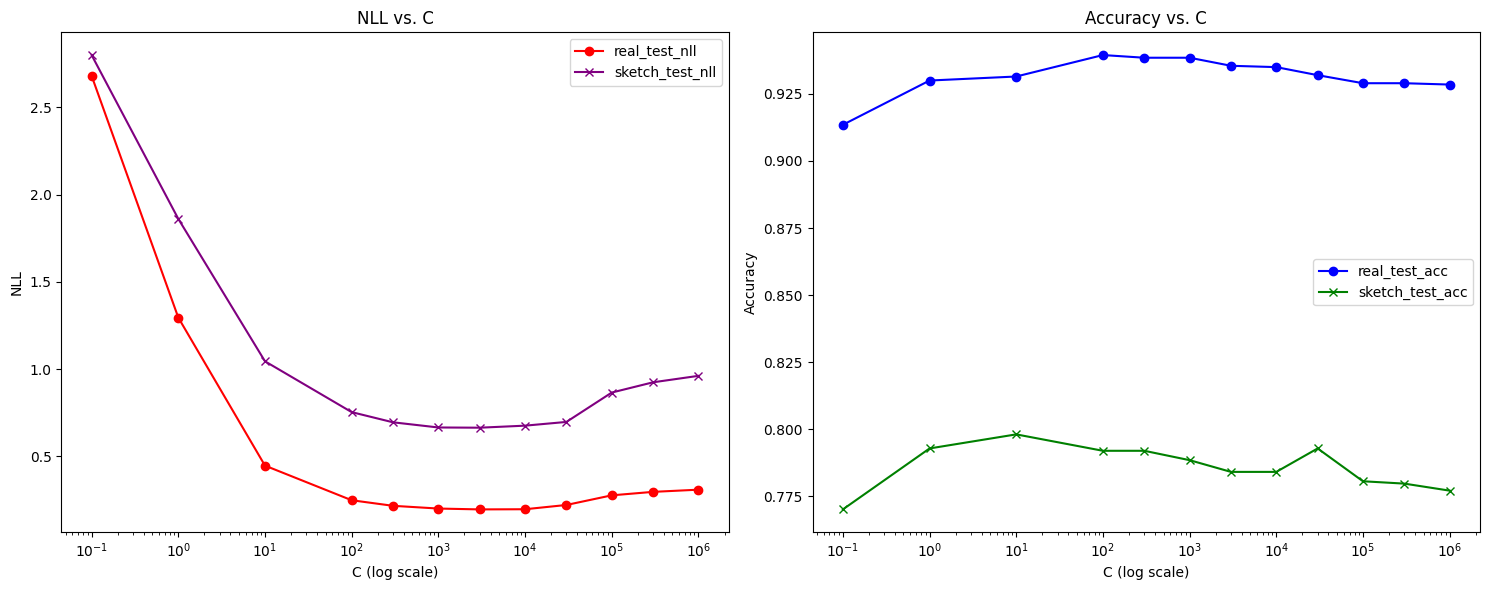

In [ ]:
X_sketch_small, X_sketch_large, y_sketch_small, y_sketch_large = train_test_split(
        X_sketch_downsampled,
        y_sketch_downsampled,
        train_size=0.2,
        stratify=y_sketch_downsampled,
        random_state=42
    )
X_combined_train1 = np.vstack((X_real_downsampled, X_sketch_small))
y_combined_train1 = np.concatenate((y_real_downsampled, y_sketch_small))

print(f"Combined train shape: {X_combined_train1.shape}")


print(f"sketch/real fraction: {X_sketch_small.shape[0]/X_real_downsampled.shape[0]}")

#candidate_Cs = [1e-6, 1e-5, 1e-4, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000]
#candidate_Cs = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000, 3000, 1e4]
candidate_Cs = [1e-1, 1, 10, 1e2, 3e2, 1000, 3000, 1e4, 3e4, 1e5, 3e5, 1e6]

candidate_models = {}
rows = []

for C in candidate_Cs:
    clf = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        #multi_class="multinomial",
        max_iter=2000, #6000,
        tol=1e-5,
    )
    clf.fit(X_combined_train1, y_combined_train1)
    candidate_models[C] = clf

    real_test_probs = clf.predict_proba(X_real_test)
    real_test_pred = clf.predict(X_real_test)

    sketch_test_probs = clf.predict_proba(X_sketch_test)
    sketch_test_pred = clf.predict(X_sketch_test)

    rows.append({
        "C": C,
        "real_test_acc": accuracy_score(y_real_test, real_test_pred),
        "real_test_nll": log_loss(y_real_test, real_test_probs, labels=clf.classes_),
        "sketch_test_acc": accuracy_score(y_sketch_test, sketch_test_pred),
        "sketch_test_nll": log_loss(y_sketch_test, sketch_test_probs, labels=clf.classes_),
    })

df_baseline = pd.DataFrame(rows).sort_values("C").reset_index(drop=True)
print(df_baseline)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

# Left plot: NLL for real and sketch
ax1.set_xlabel("C (log scale)")
ax1.set_ylabel("NLL")
ax1.plot(df_baseline["C"], df_baseline["real_test_nll"], marker="o", label="real_test_nll", color='red')
ax1.plot(df_baseline["C"], df_baseline["sketch_test_nll"], marker="x", label="sketch_test_nll", color='purple')
ax1.set_xscale("log")
ax1.legend()
ax1.set_title('NLL vs. C')

# Right plot: Accuracy for real and sketch
ax2.set_xlabel("C (log scale)")
ax2.set_ylabel("Accuracy")
ax2.plot(df_baseline["C"], df_baseline["real_test_acc"], marker="o", label="real_test_acc", color='blue')
ax2.plot(df_baseline["C"], df_baseline["sketch_test_acc"], marker="x", label="sketch_test_acc", color='green')
ax2.set_xscale("log")
ax2.legend()
ax2.set_title('Accuracy vs. C')

fig.tight_layout()
plt.show()

  fitting candidate 1/15: C=1e-05
    done in 52.3s
  fitting candidate 2/15: C=0.0001
    done in 18.7s
  fitting candidate 3/15: C=0.001
    done in 48.3s
  fitting candidate 4/15: C=0.003
    done in 26.6s
  fitting candidate 5/15: C=0.01
    done in 13.8s
  fitting candidate 6/15: C=0.03
    done in 13.1s
  fitting candidate 7/15: C=0.1
    done in 9.4s
  fitting candidate 8/15: C=0.3
    done in 3.0s
  fitting candidate 9/15: C=1
    done in 5.6s
  fitting candidate 10/15: C=3
    done in 3.0s
  fitting candidate 11/15: C=10
    done in 3.9s
  fitting candidate 12/15: C=30
    done in 4.7s
  fitting candidate 13/15: C=100
    done in 4.0s
  fitting candidate 14/15: C=1e+03
    done in 4.1s
  fitting candidate 15/15: C=100
    done in 2.7s
             C  real_test_acc  real_test_nll  sketch_test_acc  sketch_test_nll
0      0.00001       0.393555       5.455167         0.196070         5.803372
1      0.00010       0.750235       3.211012         0.454341         4.513311
2      0.

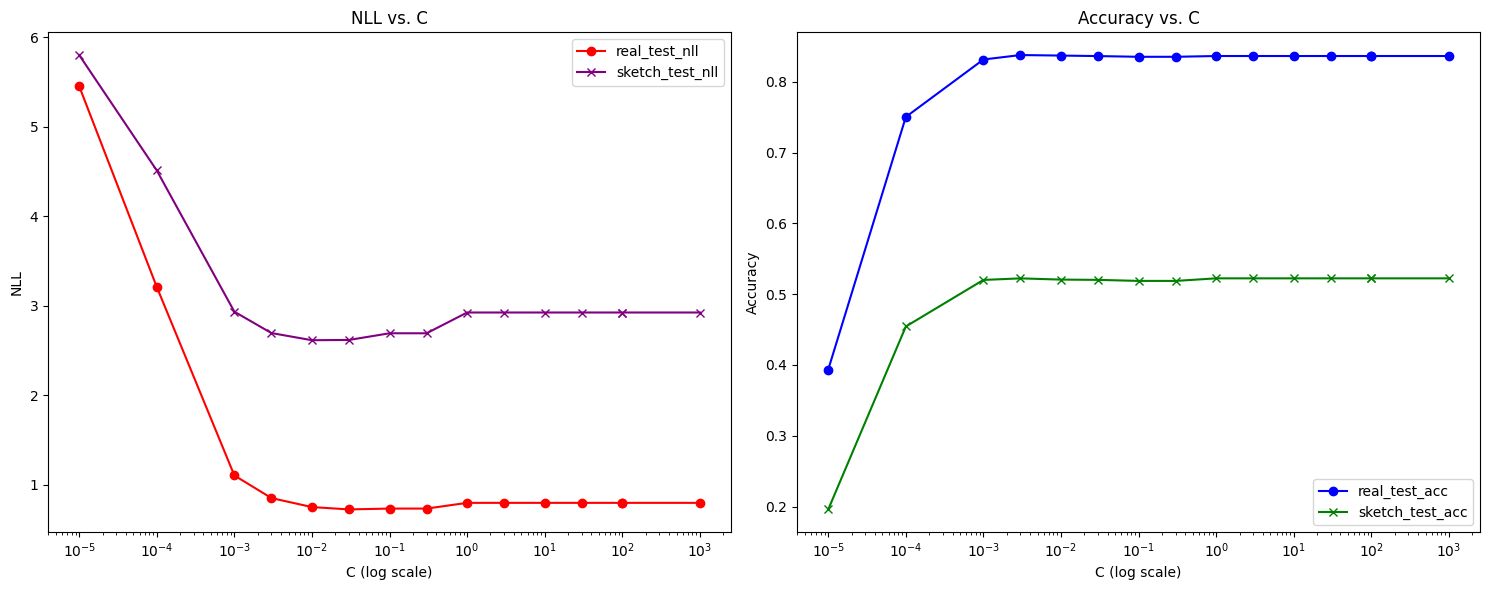

In [ ]:
import time

X_real_downsampled, _, y_real_downsampled, _ = train_test_split(
        X_real_train,
        y_real_train,
        train_size=0.1,
        stratify=y_real_train,
        random_state=42
    )

grid = [1e-5, 1e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1, 3, 10, 30, 100, 1e3, 1e2]
#candidate_Cs = [0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000, 3000, 1e4, 3e4, 1e5]
#candidate_Cs = [1e2, 3e2, 1000, 3000, 1e4, 3e4, 1e5, 3e5, 1e6]
#candidate_Cs = [1e-3, 1e-2, 3e-2, 1e-1, 1, 10, 1e2, 3e2, 1e3, 3e3, 1e4, 3e4, 1e5, 3e5, 1e6]
candidate_models = {}
rows = []

# Warm-start candidate model
clf = LogisticRegression(
    penalty="l2",
    C=grid[0],
    solver="lbfgs",
    #max_iter=2000,
    #tol=1e-5,
    #random_state=42,
    warm_start=True,
)

for j, C in enumerate(grid):
    tC = time.time()

    print(f"  fitting candidate {j+1}/{len(grid)}: C={C:.3g}", flush=True)

    clf.set_params(C=C)

    clf.fit(X_real_downsampled, y_real_downsampled)
    candidate_models[C] = clf

    real_test_probs = clf.predict_proba(X_real_test)
    real_test_pred = clf.predict(X_real_test)

    sketch_test_probs = clf.predict_proba(X_sketch_test)
    sketch_test_pred = clf.predict(X_sketch_test)

    rows.append({
        "C": C,
        "real_test_acc": accuracy_score(y_real_test, real_test_pred),
        "real_test_nll": log_loss(y_real_test, real_test_probs, labels=clf.classes_),
        "sketch_test_acc": accuracy_score(y_sketch_test, sketch_test_pred),
        "sketch_test_nll": log_loss(y_sketch_test, sketch_test_probs, labels=clf.classes_),
    })

    print(f"    done in {time.time() - tC:.1f}s", flush=True)


df_baseline = pd.DataFrame(rows).sort_values("C").reset_index(drop=True)
print(df_baseline)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

# Left plot: NLL for real and sketch
ax1.set_xlabel("C (log scale)")
ax1.set_ylabel("NLL")
ax1.plot(df_baseline["C"], df_baseline["real_test_nll"], marker="o", label="real_test_nll", color='red')
ax1.plot(df_baseline["C"], df_baseline["sketch_test_nll"], marker="x", label="sketch_test_nll", color='purple')
ax1.set_xscale("log")
ax1.legend()
ax1.set_title('NLL vs. C')

# Right plot: Accuracy for real and sketch
ax2.set_xlabel("C (log scale)")
ax2.set_ylabel("Accuracy")
ax2.plot(df_baseline["C"], df_baseline["real_test_acc"], marker="o", label="real_test_acc", color='blue')
ax2.plot(df_baseline["C"], df_baseline["sketch_test_acc"], marker="x", label="sketch_test_acc", color='green')
ax2.set_xscale("log")
ax2.legend()
ax2.set_title('Accuracy vs. C')

fig.tight_layout()
plt.show()

# Function for one seed of pseudo-labeling

In [ ]:
# 1. Identify the k=10 most frequent classes in the real training data
k = 20
samples_per_class = 20

top_classes = pd.Series(y_real_train).value_counts().nlargest(k).index

def sample_fixed_amount(X, y, classes, n_samples, seed=42):
    np.random.seed(seed)
    X_sampled = []
    y_sampled = []
    for c in classes:
        idx = np.where(y == c)[0]
        if len(idx) > n_samples:
            idx = np.random.choice(idx, n_samples, replace=False)
        else:
            print(f"Warning: Class {c} has only {len(idx)} samples, less than {n_samples}")
        X_sampled.append(X[idx])
        y_sampled.append(y[idx])
    return np.vstack(X_sampled), np.concatenate(y_sampled)

# Filter test sets to keep only the top_classes
real_test_mask = np.isin(y_real_test, top_classes)
X_real_test = X_real_test[real_test_mask]
y_real_test = y_real_test[real_test_mask]

sketch_test_mask = np.isin(y_sketch_test, top_classes)
X_sketch_test = X_sketch_test[sketch_test_mask]
y_sketch_test = y_sketch_test[sketch_test_mask]

print(f"Real test filtered shape: {X_real_test.shape}")
print(f"Sketch test filtered shape: {X_sketch_test.shape}")
print(f"Classes kept: {top_classes.values}")

Real test filtered shape: (200, 512)
Sketch test filtered shape: (63, 512)
Classes kept: [344   0 343   2   3 342   5 326 325 324 323 322 321 320 319 318 317 316
 314 313]


In [ ]:
def run_exp(
    X, y,
    X0, y0,
    X_test, y_test,
    X0_test, y0_test,
    seed,
    c_min=1e0,
    c_max=1e4,
    c_tilde=1e4,
    beta=1.8,
    grid=None,
    max_iter=2000,
    tol=1e-6,
    verbose=True,
):
    import time

    # Sample from each for real training data
    Xd, yd = sample_fixed_amount(
        X, y, top_classes, 40
    )

    # Sample from each for sketch training data
    X0_val, y0_val = sample_fixed_amount(
        X0, y0, top_classes, 100
    )

    # Split source into D1 and D2
    X1, X2, y1, y2 = train_test_split(
        Xd, yd,
        train_size=0.5,
        stratify=yd,
        random_state=seed,
    )

    # Grid
    if grid is None:
        m = np.log(c_max / c_min) / np.log(beta)
        m = max(int(np.ceil(m)), 2) + 1
        grid = c_min * (beta ** np.arange(m))
    else:
        grid = np.asarray(grid)

    grid = np.sort(grid)

    if verbose:
        print("Shapes:")
        print("  Xd:", Xd.shape)
        print("  X1:", X1.shape, "X2:", X2.shape)
        print("  X0_val:", X0_val.shape)
        print("  X0_test:", X0_test.shape)
        print("  grid size:", len(grid))
        print("  grid:", grid, flush=True)

    # Imputer trained on D2
    t0 = time.time()
    if verbose:
        print("  fitting imputer...", flush=True)

    imputer = LogisticRegression(
        penalty="l2",
        C=c_tilde,
        solver="lbfgs",
        max_iter=max_iter,
        tol=tol,
        random_state=seed,
    )
    imputer.fit(X2, y2)

    if verbose:
        print(f"  imputer done in {time.time() - t0:.1f}s", flush=True)

    pseudo_probs_D0 = imputer.predict_proba(X0_val)

    rows = []

    # Warm-start candidate model
    clf = LogisticRegression(
        penalty="l2",
        C=grid[0],
        solver="lbfgs",
        max_iter=max_iter,
        tol=tol,
        random_state=seed,
        warm_start=True,
    )

    for j, C in enumerate(grid):
        tC = time.time()

        if verbose:
            print(f"  fitting candidate {j+1}/{len(grid)}: C={C:.3g}", flush=True)

        clf.set_params(C=C)
        clf.fit(X1, y1)

        probs_D2 = clf.predict_proba(X2)
        probs_D0 = clf.predict_proba(X0_val)
        probs_D0_test = clf.predict_proba(X0_test)
        pred_D0_test = clf.predict(X0_test)

        probs_D_test = clf.predict_proba(X_test)
        pred_D_test = clf.predict(X_test)

        rows.append({
            "C": C,

            # selection risks
            "naive_risk_D2": log_loss(y2, probs_D2, labels=clf.classes_),
            "pseudo_risk_D0": soft_cross_entropy(pseudo_probs_D0, probs_D0),
            "oracle_risk_D0": log_loss(y0_val, probs_D0, labels=clf.classes_),

            # final evaluation
            "target_test_nll": log_loss(y0_test, probs_D0_test, labels=clf.classes_),
            "target_test_acc": accuracy_score(y0_test, pred_D0_test),
            "source_test_nll": log_loss(y_test, probs_D_test, labels=clf.classes_),
            "source_test_acc": accuracy_score(y_test, pred_D_test),
        })

        if verbose:
            print(f"    done in {time.time() - tC:.1f}s", flush=True)

    df_all = pd.DataFrame(rows).sort_values("C").reset_index(drop=True)

    naive_best = df_all.loc[df_all["naive_risk_D2"].idxmin()]
    pseudo_best = df_all.loc[df_all["pseudo_risk_D0"].idxmin()]
    oracle_best = df_all.loc[df_all["oracle_risk_D0"].idxmin()]

    selected = pd.DataFrame([
        {
            "method": "naive",
            "selected_C": naive_best["C"],
            "selection_risk": naive_best["naive_risk_D2"],
            "target_test_nll": naive_best["target_test_nll"],
            "target_test_acc": naive_best["target_test_acc"],
        },
        {
            "method": "pseudo",
            "selected_C": pseudo_best["C"],
            "selection_risk": pseudo_best["pseudo_risk_D0"],
            "target_test_nll": pseudo_best["target_test_nll"],
            "target_test_acc": pseudo_best["target_test_acc"],
        },
        {
            "method": "oracle",
            "selected_C": oracle_best["C"],
            "selection_risk": oracle_best["oracle_risk_D0"],
            "target_test_nll": oracle_best["target_test_nll"],
            "target_test_acc": oracle_best["target_test_acc"],
        },
    ])

    return {
        "df_all": df_all,
        "selected": selected,
        "grid": grid,
        "classes": clf.classes_,
    }

In [ ]:
#candidate_Cs = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0]
#candidate_Cs = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000, 3000]
#candidate_Cs = [0.1, 0.3, 1, 3, 10, 30, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1500, 2000, 3000, 10000]
#candidate_Cs = [1, 10, 30, 100, 200, 400, 800, 1000, 2000, 4000, 8000]
candidate_Cs = [3e-2, 0.1, 0.3, 1, 3, 10, 3, 1e2, 3e2, 1000, 3000, 1e4, 3e4, 1e5, 3e5, 1e6]

res = run_exp(X_real_train, y_real_train,
              X_sketch_train, y_sketch_train,
              X_real_test, y_real_test,
              X_sketch_test, y_sketch_test,
              seed=42,
              grid=candidate_Cs)

Shapes:
  Xd: (800, 512)
  X1: (400, 512) X2: (400, 512)
  X0_val: (1811, 512)
  X0_test: (63, 512)
  grid size: 16
  grid: [3.e-02 1.e-01 3.e-01 1.e+00 3.e+00 3.e+00 1.e+01 1.e+02 3.e+02 1.e+03
 3.e+03 1.e+04 3.e+04 1.e+05 3.e+05 1.e+06]
  fitting imputer...
  imputer done in 8.7s
  fitting candidate 1/16: C=0.03
    done in 0.5s
  fitting candidate 2/16: C=0.1
    done in 0.7s
  fitting candidate 3/16: C=0.3
    done in 2.3s
  fitting candidate 4/16: C=1
    done in 3.7s
  fitting candidate 5/16: C=3
    done in 4.1s
  fitting candidate 6/16: C=3
    done in 0.1s
  fitting candidate 7/16: C=10
    done in 6.1s
  fitting candidate 8/16: C=100
    done in 7.3s
  fitting candidate 9/16: C=300
    done in 6.0s
  fitting candidate 10/16: C=1e+03
    done in 3.4s
  fitting candidate 11/16: C=3e+03
    done in 3.4s
  fitting candidate 12/16: C=1e+04
    done in 1.8s
  fitting candidate 13/16: C=3e+04
    done in 0.7s
  fitting candidate 14/16: C=1e+05
    done in 0.1s
  fitting candidate 15

In [ ]:
selected = res["selected"]
rows = []

for _, row in selected.iterrows():
  rows.append({"method": row["method"], "nll": row["target_test_nll"], "acc": row["target_test_acc"], "C": row["selected_C"]})
df = pd.DataFrame(rows)
summary = summarize_results(df)
print(summary)

   method  mean_nll  se_nll  ci_nll  mean_acc  se_acc  ci_acc       C
0   naive  0.362675     NaN     NaN  0.873016     NaN     NaN  1000.0
1  oracle  0.362675     NaN     NaN  0.873016     NaN     NaN  1000.0
2  pseudo  0.414130     NaN     NaN  0.873016     NaN     NaN   300.0


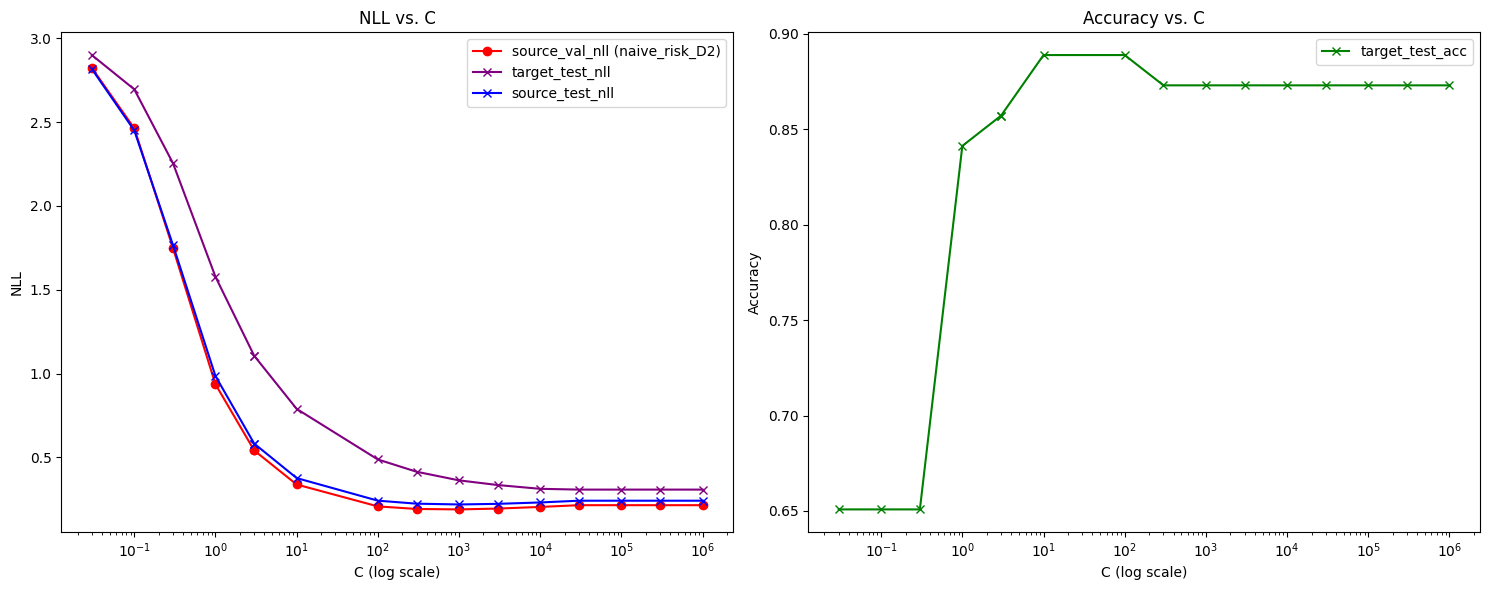

In [ ]:
df_all = res["df_all"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

# Left plot: NLL
ax1.set_xlabel("C (log scale)")
ax1.set_ylabel("NLL")
ax1.plot(df_all["C"], df_all["naive_risk_D2"], marker="o", label="source_val_nll (naive_risk_D2)", color='red')
ax1.plot(df_all["C"], df_all["target_test_nll"], marker="x", label="target_test_nll", color='purple')
ax1.plot(df_all["C"], df_all["source_test_nll"], marker="x", label="source_test_nll", color='blue')
ax1.set_xscale("log")
ax1.legend()
ax1.set_title('NLL vs. C')

# Right plot: Accuracy
ax2.set_xlabel("C (log scale)")
ax2.set_ylabel("Accuracy")
ax2.plot(df_all["C"], df_all["target_test_acc"], marker="x", label="target_test_acc", color='green')
# Note: source test/val accuracy is not recorded in df_all currently.
ax2.set_xscale("log")
ax2.legend()
ax2.set_title('Accuracy vs. C')

fig.tight_layout()
plt.show()

In [ ]:
def make_pivot(df):
    return df.pivot(index="seed", columns="method", values=["nll", "acc"])

In [ ]:
from scipy import stats

def paired_test(pivot, method_a, method_b, metric="nll"):
    a = pivot[metric][method_a]
    b = pivot[metric][method_b]

    diff = a - b
    n = len(diff)

    mean = diff.mean()
    std = diff.std(ddof=1)
    se = std / np.sqrt(n)
    ci = 1.96 * se

    # Paired t-test
    t_stat, p_value = stats.ttest_rel(a, b)

    return {
        "method_a": method_a,
        "method_b": method_b,
        "metric": metric,
        "mean_diff": mean,
        "se": se,
        "ci": ci,
        "t_stat": t_stat,
        "p_value": p_value,
    }

In [ ]:
def run_many_seeds(
    X, y,
    X0, y0,
    X_test, y_test,
    X0_test, y0_test,
    seed_list,
    verbose=True,
    **kwargs
):
    rows = []
    failed_seeds = []

    for seed in seed_list:
        print("seed", seed)
        try:
            res = run_exp(
                X, y,
                X0, y0,
                X_test, y_test,
                X0_test, y0_test,
                seed=seed,
                **kwargs
            )

            selected = res["selected"]

            for _, row in selected.iterrows():
                rows.append({
                    "seed": seed,
                    "method": row["method"],
                    "nll": row["target_test_nll"],
                    "acc": row["target_test_acc"],
                    "C": row["selected_C"],
                })

        except AssertionError as e:
            failed_seeds.append(seed)
            if verbose:
                print(f"[WARNING] Seed {seed} failed assertion: {e}")
            continue

        except Exception as e:
            failed_seeds.append(seed)
            if verbose:
                print(f"[ERROR] Seed {seed} crashed: {e}")
            continue

    df = pd.DataFrame(rows)

    if verbose:
        print(f"\nFinished: {len(seed_list) - len(failed_seeds)}/{len(seed_list)} seeds succeeded")
        if failed_seeds:
            print(f"Failed seeds: {failed_seeds}")

    return df, failed_seeds

In [ ]:
def summarize_results(df):
    summary = []

    for method, group in df.groupby("method"):
        n = len(group)

        # NLL
        mean_nll = group["nll"].mean()
        std_nll = group["nll"].std(ddof=1)
        se_nll = std_nll / np.sqrt(n)
        ci_nll = 1.96 * se_nll
        C = group["C"].mean()

        # Accuracy
        mean_acc = group["acc"].mean()
        std_acc = group["acc"].std(ddof=1)
        se_acc = std_acc / np.sqrt(n)
        ci_acc = 1.96 * se_acc

        summary.append({
            "method": method,
            "mean_nll": mean_nll,
            "se_nll": se_nll,
            "ci_nll": ci_nll,
            "mean_acc": mean_acc,
            "se_acc": se_acc,
            "ci_acc": ci_acc,
            "C": C,
        })

    return pd.DataFrame(summary)

In [ ]:
seed_list = list(range(50))  # or your custom seeds

df_all, failed_seeds = run_many_seeds(
    X=X_real_train, y=y_real_train,
    X0=X_sketch_train, y0=y_sketch_train,
    X_test=X_real_test, y_test=y_real_test,
    X0_test=X_sketch_test, y0_test=y_sketch_test,
    seed_list=seed_list,
)

summary = summarize_results(df_all)

pivot = make_pivot(df_all)

print(summary)

seed 0
Shapes:
  Xd: (39460, 512)
  X1: (7892, 512) X2: (31568, 512)
  X0_val: (33325, 512)
  X0_test: (18900, 512)
  num_classes: 345
  grid size: 17
  grid: [1.00000000e+00 1.80000000e+00 3.24000000e+00 5.83200000e+00
 1.04976000e+01 1.88956800e+01 3.40122240e+01 6.12220032e+01
 1.10199606e+02 1.98359290e+02 3.57046723e+02 6.42684101e+02
 1.15683138e+03 2.08229649e+03 3.74813368e+03 6.74664062e+03
 1.21439531e+04]
  fitting imputer...
  imputer done in 295.9s
  fitting candidate 1/17: C=1
    done in 15.6s
  fitting candidate 2/17: C=1.8
    done in 16.2s
  fitting candidate 3/17: C=3.24
    done in 17.0s
  fitting candidate 4/17: C=5.83
    done in 20.7s
  fitting candidate 5/17: C=10.5
    done in 25.1s
  fitting candidate 6/17: C=18.9
    done in 24.6s
  fitting candidate 7/17: C=34
    done in 25.3s
  fitting candidate 8/17: C=61.2
    done in 25.6s
  fitting candidate 9/17: C=110
    done in 24.0s
  fitting candidate 10/17: C=198
    done in 19.6s
  fitting candidate 11/17: C=35

In [ ]:
summary = summarize_results(df_all)

pivot = make_pivot(df_all)

print(summary)

   method  mean_nll    se_nll    ci_nll  mean_acc    se_acc    ci_acc
0   naive  2.111909  0.003824  0.007495  0.570805  0.000683  0.001338
1  oracle  2.103724  0.003484  0.006829  0.570397  0.000667  0.001308
2  pseudo  2.104947  0.003663  0.007179  0.570456  0.000672  0.001317


In [ ]:
comparisons = []

comparisons.append(paired_test(pivot, "pseudo", "naive", "nll"))
comparisons.append(paired_test(pivot, "pseudo", "oracle", "nll"))
comparisons.append(paired_test(pivot, "naive", "oracle", "nll"))

comparisons.append(paired_test(pivot, "pseudo", "naive", "acc"))
comparisons.append(paired_test(pivot, "pseudo", "oracle", "acc"))

df_comp = pd.DataFrame(comparisons)
print(df_comp)

  method_a method_b metric  mean_diff        se        ci     t_stat  \
0   pseudo    naive    nll  -0.006963  0.000553  0.001084 -12.584104   
1   pseudo   oracle    nll   0.001222  0.000456  0.000894   2.678332   
2    naive   oracle    nll   0.008185  0.000409  0.000801  20.026977   
3   pseudo    naive    acc  -0.000349  0.000070  0.000138  -4.965733   
4   pseudo   oracle    acc   0.000059  0.000039  0.000075   1.539162   

        p_value  
0  5.762706e-17  
1  1.004218e-02  
2  3.039705e-25  
3  8.700108e-06  
4  1.301983e-01  


# Splits and training

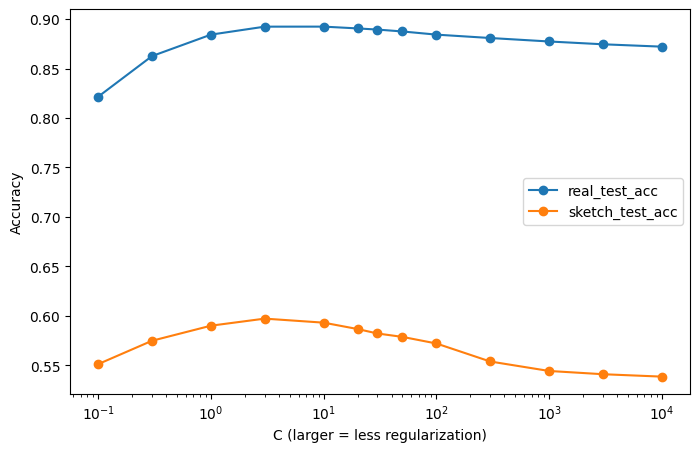

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(df_all["C"], df_all["real_test_acc"], marker="o", label="real_test_acc")
plt.plot(df_all["C"], df_all["sketch_test_acc"], marker="o", label="sketch_test_acc")
plt.xscale("log")
plt.xlabel("C (larger = less regularization)")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

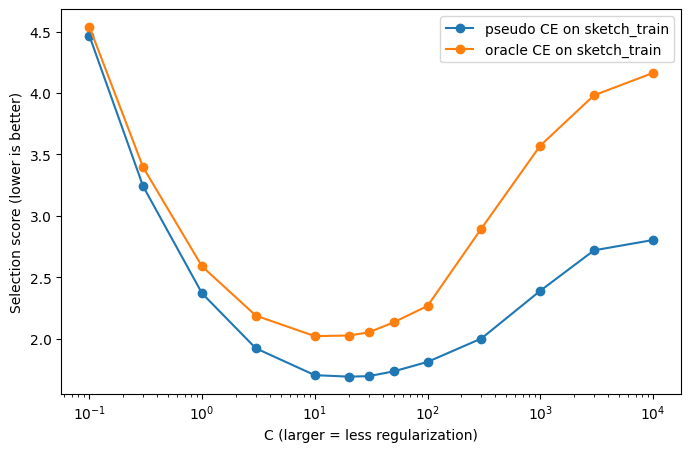

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(df_all["C"], df_all["pseudo_ce_on_sketch_train"], marker="o", label="pseudo CE on sketch_train")
plt.plot(df_all["C"], df_all["oracle_ce_on_sketch_train"], marker="o", label="oracle CE on sketch_train")
plt.xscale("log")
plt.xlabel("C (larger = less regularization)")
plt.ylabel("Selection score (lower is better)")
plt.legend()
plt.show()

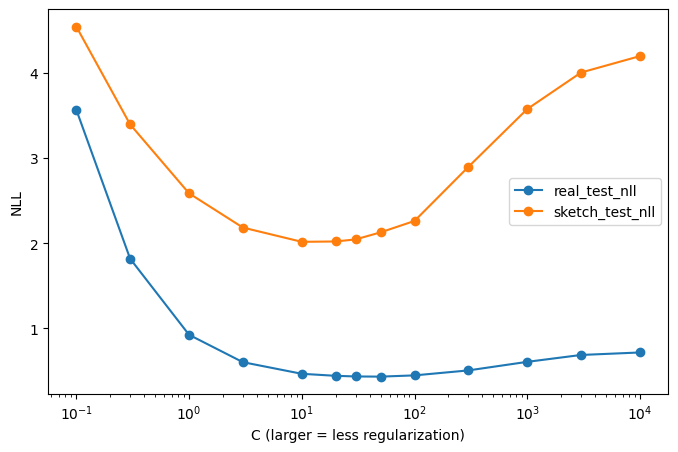

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(df_all["C"], df_all["real_test_nll"], marker="o", label="real_test_nll")
plt.plot(df_all["C"], df_all["sketch_test_nll"], marker="o", label="sketch_test_nll")
plt.xscale("log")
plt.xlabel("C (larger = less regularization)")
plt.ylabel("NLL")
plt.legend()
plt.show()

# Multiple seeds

In [ ]:
candidate_Cs = [0.1, 0.3, 1, 3, 10, 20, 30, 50, 100, 300, 1000, 3000, 10000]

def run_one_exp(candidate_grid=candidate_Cs, C_imp=10000, seed=0):
  # source train split
  cand_idx, imp_idx = stratified_split_two_parts(X_real_train, y_real_train, fraction_first=0.5, seed=seed)

  X_cand, y_cand = X_real_train[cand_idx], y_real_train[cand_idx]
  X_imp, y_imp = X_real_train[imp_idx], y_real_train[imp_idx]

  num_classes = len(np.unique(y_real_train))

  # train candidate models
  candidate_models = {}
  rows = []

  for C in candidate_Cs:
      clf = LogisticRegression(
          penalty="l2",
          C=C,
          solver="lbfgs",
          multi_class="multinomial",
          max_iter=2000,
          random_state=seed
      )
      clf.fit(X_cand, y_cand)
      candidate_models[C] = clf

      real_test_probs = clf.predict_proba(X_real_test)
      real_test_pred = np.argmax(real_test_probs, axis=1)

      sketch_test_probs = clf.predict_proba(X_sketch_test)
      sketch_test_pred = np.argmax(sketch_test_probs, axis=1)

      rows.append({
          "C": C,
          "real_test_acc": accuracy_score(y_real_test, real_test_pred),
          "real_test_nll": log_loss(y_real_test, real_test_probs, labels=np.arange(num_classes)),
          "sketch_test_acc": accuracy_score(y_sketch_test, sketch_test_pred),
          "sketch_test_nll": log_loss(y_sketch_test, sketch_test_probs, labels=np.arange(num_classes)),
      })

  df_baseline = pd.DataFrame(rows).sort_values("C").reset_index(drop=True)
  df_baseline
  best_source = df_baseline.loc[df_baseline["real_test_nll"].idxmin()]
  best_target = df_baseline.loc[df_baseline["sketch_test_nll"].idxmin()]

  # Train imputer and compute pseudo soft labels
  imputer_C = C_imp

  imputer = LogisticRegression(
      penalty="l2",
      C=imputer_C,
      solver="lbfgs",
      multi_class="multinomial",
      max_iter=2000,
      random_state=seed
  )
  imputer.fit(X_imp, y_imp)

  pseudo_probs_sketch_train = imputer.predict_proba(X_sketch_train)

  oracle_soft_targets_sketch_train = one_hot(y_sketch_train, num_classes)

  # Model selection
  selection_rows = []

  for C, clf in candidate_models.items():
      probs_sketch_train = clf.predict_proba(X_sketch_train)
      probs_sketch_test = clf.predict_proba(X_sketch_test)
      pred_sketch_test = np.argmax(probs_sketch_test, axis=1)

      selection_rows.append({
          "C": C,
          "pseudo_ce_on_sketch_train": soft_cross_entropy(pseudo_probs_sketch_train, probs_sketch_train),
          "oracle_ce_on_sketch_train": soft_cross_entropy(oracle_soft_targets_sketch_train, probs_sketch_train),
          "sketch_test_acc": accuracy_score(y_sketch_test, pred_sketch_test),
          "sketch_test_nll": log_loss(y_sketch_test, probs_sketch_test, labels=np.arange(num_classes)),
      })

  df_select = pd.DataFrame(selection_rows).sort_values("C").reset_index(drop=True)
  df_select

  pseudo_best = df_select.loc[df_select["pseudo_ce_on_sketch_train"].idxmin()]
  oracle_train_best = df_select.loc[df_select["oracle_ce_on_sketch_train"].idxmin()]
  oracle_test_best = df_select.loc[df_select["sketch_test_nll"].idxmin()]

  # Concatenate results
  df_all = df_baseline.merge(df_select[["C", "pseudo_ce_on_sketch_train", "oracle_ce_on_sketch_train"]], on="C")
  df_all = df_all.sort_values("C").reset_index(drop=True)

  return df_all, pseudo_best, oracle_train_best, oracle_test_best, best_source, best_target

In [ ]:
seed_list = [42, 1234, 2026, 9001, 88, 555, 101, 99]
df_all_list = []
pseudo_best_list = []
oracle_train_best_list = []
oracle_test_best_list = []
best_source_list = []
best_target_list = []

for seed in seed_list:
  df_all, pseudo_best, oracle_train_best, oracle_test_best, best_source, best_target = run_one_exp(seed=seed)
  df_all_list.append(df_all)
  pseudo_best_list.append(pseudo_best)
  oracle_train_best_list.append(oracle_train_best)
  oracle_test_best_list.append(oracle_test_best)
  best_source_list.append(best_source)
  best_target_list.append(best_target)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

In [ ]:
pseudo_df = pd.DataFrame(pseudo_best_list).copy()
oracle_train_df = pd.DataFrame(oracle_train_best_list).copy()
oracle_test_df = pd.DataFrame(oracle_test_best_list).copy()
source_df = pd.DataFrame(best_source_list).copy()

pseudo_df["selector"] = "pseudo"
oracle_train_df["selector"] = "oracle_train"
oracle_test_df["selector"] = "oracle_test"
source_df["selector"] = "source"

summary_df = pd.concat(
    [pseudo_df, oracle_train_df, oracle_test_df, source_df],
    ignore_index=True
)

summary_df["seed"] = seed_list * 4
summary_df.head()

,C,pseudo_ce_on_sketch_train,oracle_ce_on_sketch_train,sketch_test_acc,sketch_test_nll,selector,real_test_acc,real_test_nll,seed
0,20.0,1.673226,2.040565,0.580106,2.034878,pseudo,NaN,NaN,42
1,20.0,1.730033,2.042329,0.581640,2.039813,pseudo,NaN,NaN,1234
2,20.0,1.721448,2.033372,0.588042,2.024752,pseudo,NaN,NaN,2026
3,20.0,1.684823,2.031070,0.582169,2.016702,pseudo,NaN,NaN,9001
4,30.0,1.618353,2.059585,0.578519,2.050457,pseudo,NaN,NaN,88


In [ ]:
oracle_test_acc_by_seed = {
    seed: row["sketch_test_acc"]
    for seed, row in zip(seed_list, oracle_test_best_list)
}

summary_df["oracle_test_acc_for_seed"] = summary_df["seed"].map(oracle_test_acc_by_seed)
summary_df["regret_vs_oracle_test"] = (
    summary_df["oracle_test_acc_for_seed"] - summary_df["sketch_test_acc"]
)

summary_df[["seed", "selector", "C", "sketch_test_acc", "regret_vs_oracle_test"]].head(12)

,seed,selector,C,sketch_test_acc,regret_vs_oracle_test
0,42,pseudo,20.0,0.580106,0.006508
1,1234,pseudo,20.0,0.581640,0.005185
2,2026,pseudo,20.0,0.588042,0.000000
3,9001,pseudo,20.0,0.582169,0.000000
4,88,pseudo,30.0,0.578519,0.009418
5,555,pseudo,30.0,0.583598,0.007778
6,101,pseudo,20.0,0.578042,0.005926
7,99,pseudo,20.0,0.584656,0.000000
8,42,oracle_train,10.0,0.586614,0.000000
9,1234,oracle_train,10.0,0.586825,0.000000


                n      mean       std        se    ci_low   ci_high
selector                                                           
oracle_test   8.0  0.586448  0.002850  0.001008  0.584473  0.588424
oracle_train  8.0  0.586448  0.002850  0.001008  0.584473  0.588424
pseudo        8.0  0.582097  0.003329  0.001177  0.579790  0.584403
source        8.0  0.578399  0.005275  0.001865  0.574744  0.582055
                n      mean       std       se    ci_low   ci_high
selector                                                          
oracle_test   8.0  0.000000  0.000000  0.00000  0.000000  0.000000
oracle_train  8.0  0.000000  0.000000  0.00000  0.000000  0.000000
pseudo        8.0  0.004352  0.003818  0.00135  0.001706  0.006998
source        8.0  0.008049  0.004411  0.00156  0.004992  0.011106
                n   mean        std        se     ci_low    ci_high
selector                                                           
oracle_test   8.0  13.75   5.175492  1.829813  10.1635

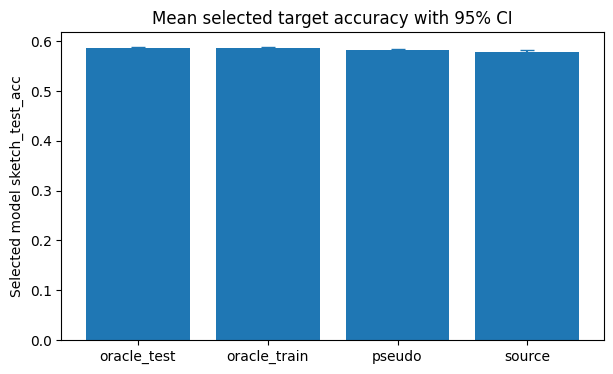

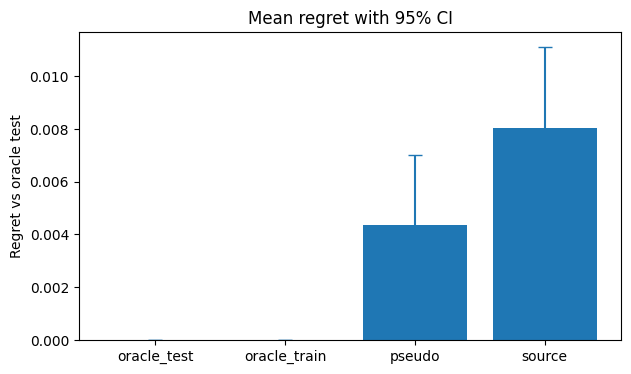

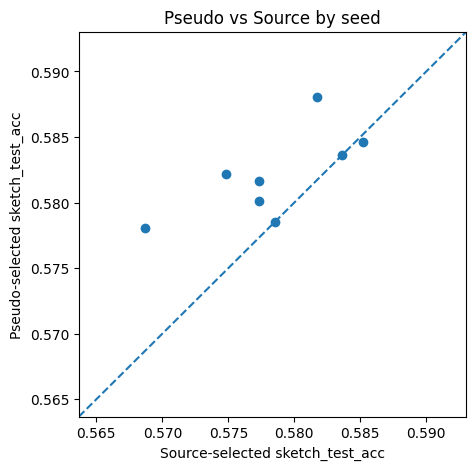

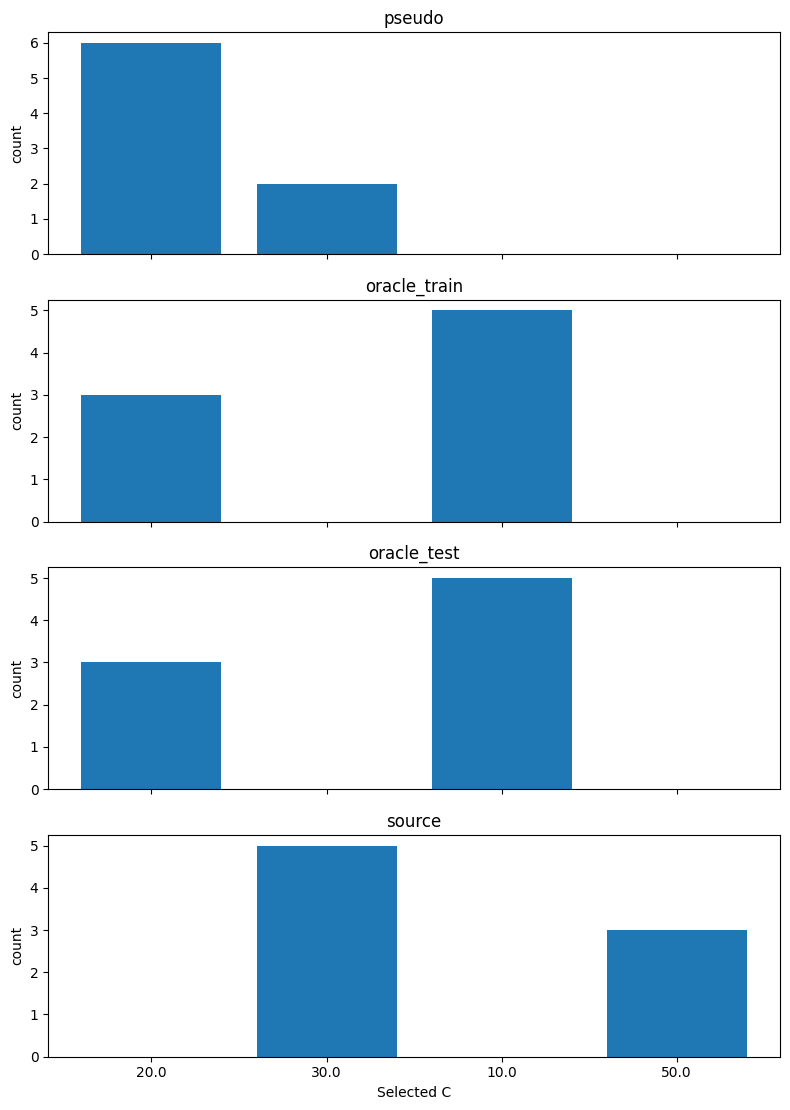

        real_test_acc           sketch_test_acc            \
                 mean       std            mean       std   
C                                                           
0.1          0.821475  0.000735        0.549544  0.001341   
0.3          0.862990  0.000605        0.572877  0.001681   
1.0          0.883448  0.000848        0.586091  0.001535   
3.0          0.891103  0.000818        0.594372  0.002028   
10.0         0.891395  0.000409        0.588208  0.002596   
20.0         0.889133  0.000792        0.582659  0.003059   
30.0         0.887964  0.000788        0.579425  0.003870   
50.0         0.886056  0.001001        0.575919  0.004237   
100.0        0.883621  0.000811        0.568981  0.004626   
300.0        0.880093  0.001016        0.555231  0.004285   
1000.0       0.876897  0.001221        0.544193  0.007936   
3000.0       0.873619  0.000672        0.540020  0.006009   
10000.0      0.870515  0.002218        0.534478  0.007844   

        pseudo_ce_on_sk

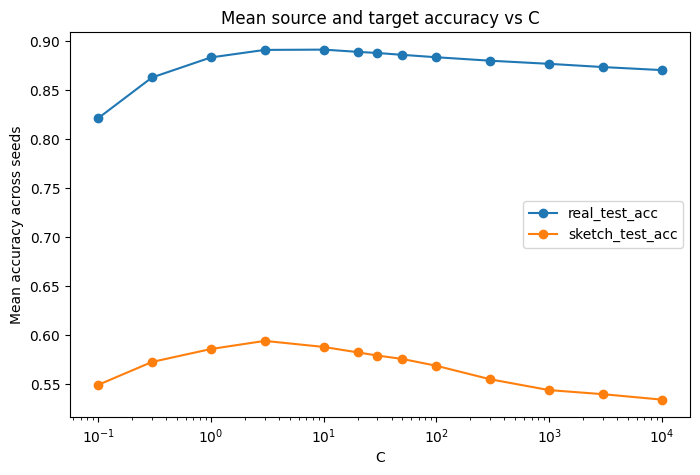

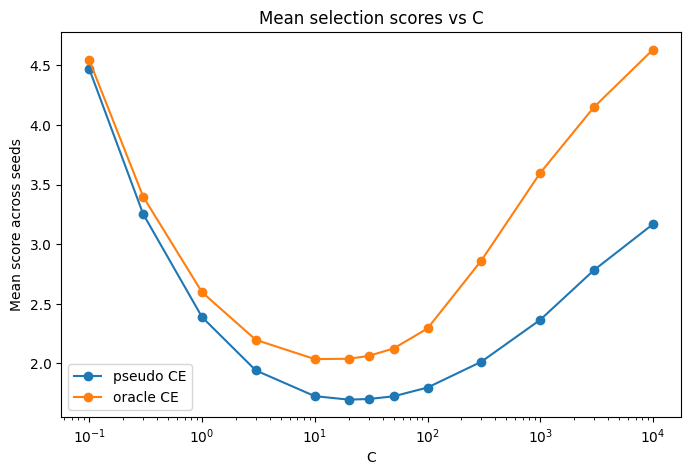

              acc_n  acc_mean   acc_std    acc_se  acc_ci_low  acc_ci_high  \
selector                                                                     
oracle_test     8.0  0.586448  0.002850  0.001008    0.584473     0.588424   
oracle_train    8.0  0.586448  0.002850  0.001008    0.584473     0.588424   
pseudo          8.0  0.582097  0.003329  0.001177    0.579790     0.584403   
source          8.0  0.578399  0.005275  0.001865    0.574744     0.582055   

              regret_n  regret_mean  regret_std  regret_se  regret_ci_low  \
selector                                                                    
oracle_test        8.0     0.000000    0.000000    0.00000       0.000000   
oracle_train       8.0     0.000000    0.000000    0.00000       0.000000   
pseudo             8.0     0.004352    0.003818    0.00135       0.001706   
source             8.0     0.008049    0.004411    0.00156       0.004992   

              regret_ci_high  C_n  C_mean      C_std      C_se   C_c

In [ ]:
# Mean and 95% confidence intervals
def mean_ci(x, alpha=0.95):
    x = np.asarray(x, dtype=float)
    n = len(x)
    mean = x.mean()
    std = x.std(ddof=1) if n > 1 else 0.0
    se = std / np.sqrt(n) if n > 1 else 0.0
    z = 1.96  # fine for n=8 as a simple approximation
    lo = mean - z * se
    hi = mean + z * se
    return pd.Series({
        "n": n,
        "mean": mean,
        "std": std,
        "se": se,
        "ci_low": lo,
        "ci_high": hi,
    })

#For selected sketch_test_acc
acc_summary = (
    summary_df
    .groupby("selector")["sketch_test_acc"]
    .apply(mean_ci)
    .unstack()
    .sort_values("mean", ascending=False)
)

print(acc_summary)
#For regret
regret_summary = (
    summary_df
    .groupby("selector")["regret_vs_oracle_test"]
    .apply(mean_ci)
    .unstack()
    .sort_values("mean", ascending=True)
)

print(regret_summary)
#For selected C
C_summary = (
    summary_df
    .groupby("selector")["C"]
    .apply(mean_ci)
    .unstack()
)

print(C_summary)

# Pairwise comparisons you really care about Especially pseudo vs source.
pair_df = (
    summary_df[["seed", "selector", "sketch_test_acc", "regret_vs_oracle_test"]]
    .pivot(index="seed", columns="selector", values=["sketch_test_acc", "regret_vs_oracle_test"])
)

print(pair_df)

#Difference in target accuracy: pseudo minus source
pair_df["acc_diff_pseudo_minus_source"] = (
    pair_df[("sketch_test_acc", "pseudo")] - pair_df[("sketch_test_acc", "source")]
)

pair_df["regret_diff_source_minus_pseudo"] = (
    pair_df[("regret_vs_oracle_test", "source")] - pair_df[("regret_vs_oracle_test", "pseudo")]
)

print(pair_df[["acc_diff_pseudo_minus_source", "regret_diff_source_minus_pseudo"]])

#Mean and CI of the gain
acc_gain_summary = mean_ci(pair_df["acc_diff_pseudo_minus_source"])
regret_gain_summary = mean_ci(pair_df["regret_diff_source_minus_pseudo"])

print("Pseudo minus Source: sketch_test_acc")
print(acc_gain_summary)
print()
print("Source regret minus Pseudo regret")
print(regret_gain_summary)
#If acc_diff_pseudo_minus_source is positive on average, pseudo is better.

#Bar plot with 95% CI

plot_df = acc_summary.reset_index()

plt.figure(figsize=(7, 4))
plt.bar(plot_df["selector"], plot_df["mean"])
plt.errorbar(
    x=np.arange(len(plot_df)),
    y=plot_df["mean"],
    yerr=[plot_df["mean"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["mean"]],
    fmt="none",
    capsize=5
)
plt.ylabel("Selected model sketch_test_acc")
plt.title("Mean selected target accuracy with 95% CI")
plt.show()

#Regret plot with 95% CI
plot_df = regret_summary.reset_index()

plt.figure(figsize=(7, 4))
plt.bar(plot_df["selector"], plot_df["mean"])
plt.errorbar(
    x=np.arange(len(plot_df)),
    y=plot_df["mean"],
    yerr=[plot_df["mean"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["mean"]],
    fmt="none",
    capsize=5
)
plt.ylabel("Regret vs oracle test")
plt.title("Mean regret with 95% CI")
plt.show()
#Lower is better here.

#Per-seed scatter plot: pseudo vs source This is often the most informative quick figure.
x = pair_df[("sketch_test_acc", "source")]
y = pair_df[("sketch_test_acc", "pseudo")]

plt.figure(figsize=(5, 5))
plt.scatter(x, y)
lims = [
    min(x.min(), y.min()) - 0.005,
    max(x.max(), y.max()) + 0.005
]
plt.plot(lims, lims, "--")
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Source-selected sketch_test_acc")
plt.ylabel("Pseudo-selected sketch_test_acc")
plt.title("Pseudo vs Source by seed")
plt.show()
#Points above the diagonal mean pseudo beats source.

#Which C gets selected how often
selection_counts = (
    summary_df.groupby(["selector", "C"])
    .size()
    .reset_index(name="count")
)

selection_counts.sort_values(["selector", "C"])
#And a plot:
selectors = summary_df["selector"].unique()

fig, axes = plt.subplots(len(selectors), 1, figsize=(8, 2.8 * len(selectors)), sharex=True)

if len(selectors) == 1:
    axes = [axes]

for ax, sel in zip(axes, selectors):
    sub = selection_counts[selection_counts["selector"] == sel]
    ax.bar(sub["C"].astype(str), sub["count"])
    ax.set_title(sel)
    ax.set_ylabel("count")

axes[-1].set_xlabel("Selected C")
plt.tight_layout()
plt.show()

#Aggregate the full curves over seeds
#This is useful for visualizing mean accuracy or mean pseudo-risk as a function of C.
#Assuming each df_all has the full grid results:
all_curves = []

for seed, df in zip(seed_list, df_all_list):
    temp = df.copy()
    temp["seed"] = seed
    all_curves.append(temp)

all_curves_df = pd.concat(all_curves, ignore_index=True)
all_curves_df.head()
#Mean curve by C
curve_summary = (
    all_curves_df
    .groupby("C")[["real_test_acc", "sketch_test_acc", "pseudo_ce_on_sketch_train", "oracle_ce_on_sketch_train"]]
    .agg(["mean", "std"])
)

print(curve_summary)
#Plot mean accuracy curves
curve_mean = (
    all_curves_df
    .groupby("C")[["real_test_acc", "sketch_test_acc"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(curve_mean["C"], curve_mean["real_test_acc"], marker="o", label="real_test_acc")
plt.plot(curve_mean["C"], curve_mean["sketch_test_acc"], marker="o", label="sketch_test_acc")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Mean accuracy across seeds")
plt.title("Mean source and target accuracy vs C")
plt.legend()
plt.show()
#Plot mean selection-score curves
curve_mean = (
    all_curves_df
    .groupby("C")[["pseudo_ce_on_sketch_train", "oracle_ce_on_sketch_train"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(curve_mean["C"], curve_mean["pseudo_ce_on_sketch_train"], marker="o", label="pseudo CE")
plt.plot(curve_mean["C"], curve_mean["oracle_ce_on_sketch_train"], marker="o", label="oracle CE")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Mean score across seeds")
plt.title("Mean selection scores vs C")
plt.legend()
plt.show()

#Minimal final summary table
#This is probably the one you will want in practice:
final_table = pd.concat(
    [
        acc_summary.add_prefix("acc_"),
        regret_summary.add_prefix("regret_"),
        C_summary.add_prefix("C_"),
    ],
    axis=1
)

print(final_table)
